In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [7]:
with open("../data/raw/tas_GISTEMP.csv", "r", encoding="utf-8") as f:
    for i in range(20):
        print(f.readline().strip())

Conventions,G,BADC-CSV,1
title,G,Global mean temperature
last_revised_date,G,2023-03-03
date_valid,G,2023-03-03
feature_type,G,area average
creator,G,WMO
source,G,Produced by climind version 0.1
observation_station,G,derived data
location,G,90.,-180.,-90.,180.
activity,G,WMO
history,G,"Data set created from file ['GLB.Ts+dSST.csv'] downloaded from ['https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv'] at ['2023-02-27 09:16:55']"
history,G,"Rebaselined to 1981-2010 for each month separately by calculating the arithmetic mean of the data over the baseline period and subtracting the mean from all data values. This is done for each month separately (Januarys, Februarys etc)."
history,G,"Calculated annual average from monthly averages using arithmetic mean"
history,G,"Selected years within the range 1850 to 2022."
history,G,"Added offset of 0.69 to all data values."
history,G,"Manually changed baseline to 1850-1900. Note that data values remain unchanged."
reference,G,"Lenssen,

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

DATA_DIR = Path("../data/raw")


def load_badc_csv(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    data_start = None
    for i, line in enumerate(lines):
        if line.strip().lower() == "data":
            data_start = i + 1
            break

    if data_start is None:
        raise ValueError(f"Could not find 'data' section in {file_path}")

    df = pd.read_csv(file_path, skiprows=data_start)

    # clean column names
    df.columns = [col.strip().lower() for col in df.columns]

    # keep only useful columns if they exist
    keep_cols = [col for col in ["year", "data"] if col in df.columns]
    df = df[keep_cols].copy()

    # convert types
    for col in keep_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna().copy()
    df["year"] = df["year"].astype(int)

    return df

In [9]:
gistemp = load_badc_csv(DATA_DIR / "tas_GISTEMP.csv")
noaa = load_badc_csv(DATA_DIR / "tas_NOAAGlobalTemp.csv")
hadcrut = load_badc_csv(DATA_DIR / "tas_HadCRUT5.csv")
berkeley = load_badc_csv(DATA_DIR / "tas_Berkeley_Earth.csv")
era5 = load_badc_csv(DATA_DIR / "tas_ERA5.csv")
jra55 = load_badc_csv(DATA_DIR / "tas_JRA-55.csv")

In [10]:
gistemp.head()

,year,data
0,1880,0.0988
1,1881,0.1829
2,1882,0.1562
3,1883,0.0929
4,1884,-0.0154


In [11]:
gistemp.info()

<class 'pandas.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    143 non-null    int64  
 1   data    143 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 2.4 KB


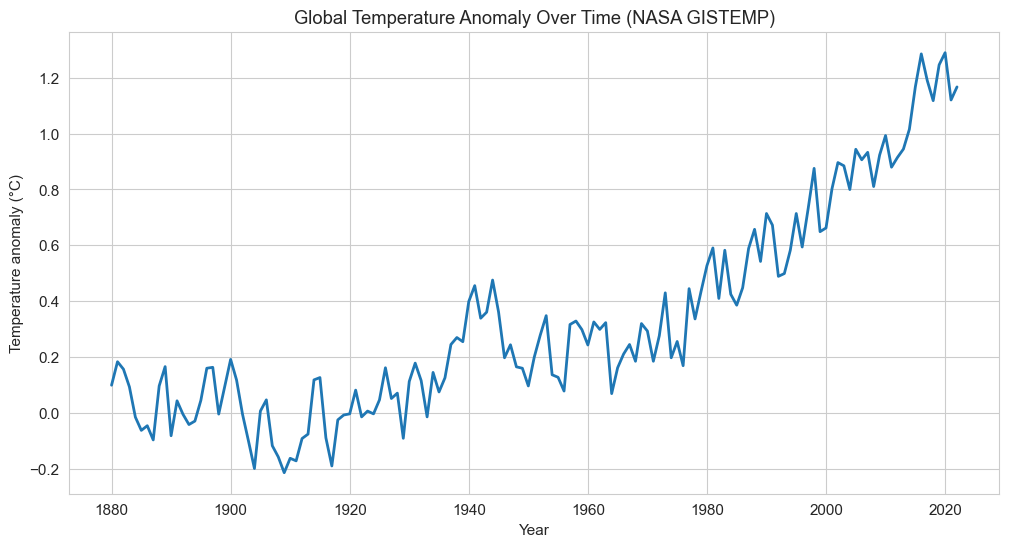

In [12]:
plt.figure()
plt.plot(gistemp["year"], gistemp["data"], linewidth=2)
plt.title("Global Temperature Anomaly Over Time (NASA GISTEMP)")
plt.xlabel("Year")
plt.ylabel("Temperature anomaly (°C)")
plt.show()

### Global Temperature Anomaly Over Time (GISTEMP)

This graph shows the evolution of global temperature anomalies based on NASA’s GISTEMP dataset. A temperature anomaly represents how much warmer or cooler a given year is compared to a historical baseline average. The chart reveals a clear upward trend in global temperatures over time, particularly from the late 20th century onwards. This pattern highlights the ongoing warming of the planet, which is widely associated with increased greenhouse gas emissions and human-driven climate change.

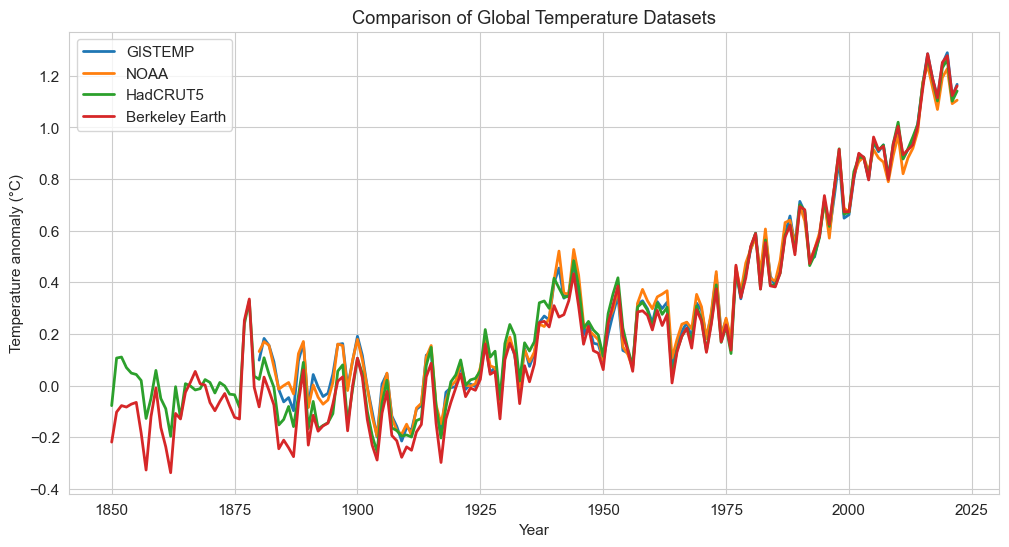

In [13]:
plt.figure()

plt.plot(gistemp["year"], gistemp["data"], label="GISTEMP", linewidth=2)
plt.plot(noaa["year"], noaa["data"], label="NOAA", linewidth=2)
plt.plot(hadcrut["year"], hadcrut["data"], label="HadCRUT5", linewidth=2)
plt.plot(berkeley["year"], berkeley["data"], label="Berkeley Earth", linewidth=2)

plt.title("Comparison of Global Temperature Datasets")
plt.xlabel("Year")
plt.ylabel("Temperature anomaly (°C)")
plt.legend()
plt.show()

### Comparison of Global Temperature Datasets

This graph compares several independent global temperature datasets, including NASA GISTEMP, NOAA GlobalTemp, HadCRUT5, and Berkeley Earth. Although these datasets are produced by different scientific organizations and rely on different methodologies, they all show a very similar upward trend. The strong agreement between these datasets reinforces the scientific consensus that the Earth's climate has been warming significantly over the past century.

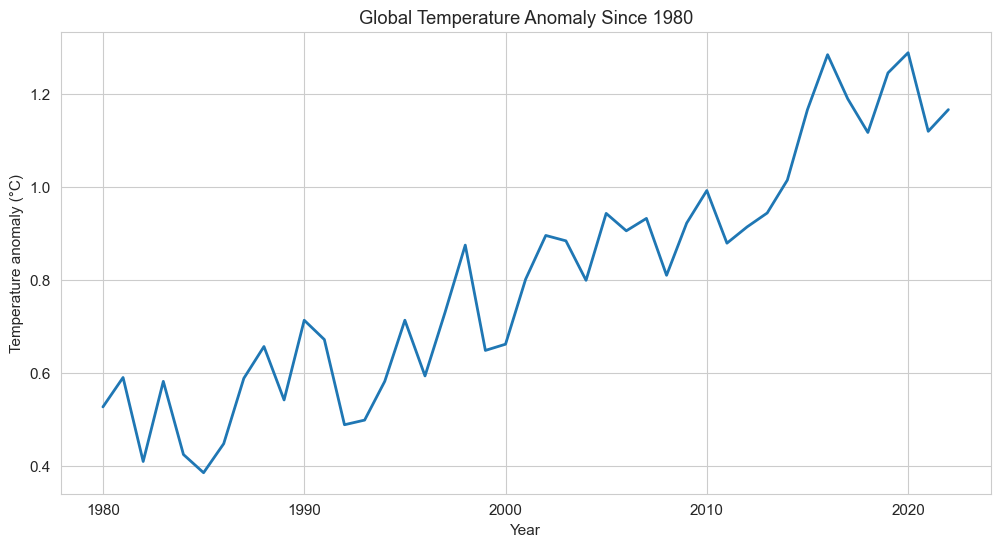

In [14]:
recent = gistemp[gistemp["year"] >= 1980].copy()

plt.figure()
plt.plot(recent["year"], recent["data"], linewidth=2)
plt.title("Global Temperature Anomaly Since 1980")
plt.xlabel("Year")
plt.ylabel("Temperature anomaly (°C)")
plt.show()

### Global Temperature Anomaly Since 1980

This chart focuses on global temperature anomalies from 1980 onward, highlighting the acceleration of global warming in recent decades. The steady increase shown in the graph indicates that global temperatures have risen rapidly over the past forty years. This period coincides with growing industrialization, increased energy consumption, and rising concentrations of greenhouse gases in the atmosphere.

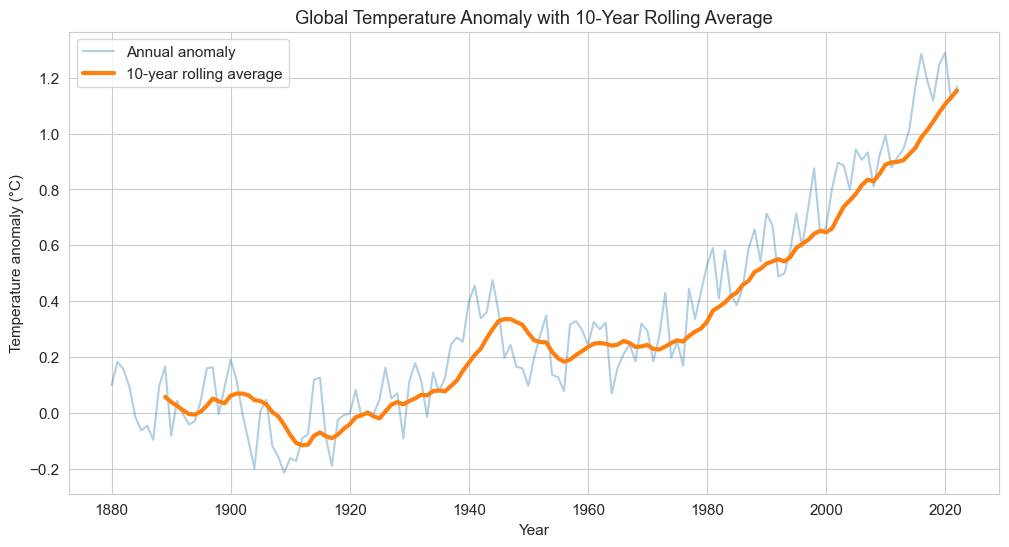

In [15]:
gistemp["rolling_10"] = gistemp["data"].rolling(10).mean()

plt.figure()
plt.plot(gistemp["year"], gistemp["data"], alpha=0.35, label="Annual anomaly")
plt.plot(gistemp["year"], gistemp["rolling_10"], linewidth=3, label="10-year rolling average")

plt.title("Global Temperature Anomaly with 10-Year Rolling Average")
plt.xlabel("Year")
plt.ylabel("Temperature anomaly (°C)")
plt.legend()
plt.show()

### Temperature Anomaly with 10-Year Rolling Average

This graph presents global temperature anomalies together with a 10-year rolling average, which smooths short-term fluctuations in the data. Individual years may vary due to natural climate variability such as El Niño events or volcanic activity. However, the rolling average highlights the long-term warming trend, making the sustained increase in global temperatures over recent decades even more apparent.

In [20]:
climate = pd.read_csv("../data/raw/Beginner_Climate_Change_Dataset_20_Features_1200_Rows.csv")

climate.head()

,year,country,global_avg_temperature,temperature_anomaly,max_temperature,min_temperature,co2_concentration_ppm,annual_rainfall_mm,sea_level_rise_mm,sea_surface_temperature,heatwave_days,drought_index,flood_events_count,forest_cover_percent,deforestation_rate,fossil_fuel_consumption,renewable_energy_share,air_quality_index,predicted_temperature_2050,climate_risk_index
0,2018,Germany,14.03,1.16,37.02,4.31,387.85,814.11,2.14,14.38,50,0.85,11,64.33,1.26,28.14,42.30,148,3.30,23.69
1,2008,India,15.03,1.05,32.25,-0.44,407.24,735.61,4.19,15.33,37,1.01,11,42.69,0.62,86.40,53.65,50,2.63,70.10
2,1994,Pakistan,14.86,1.24,41.57,1.08,450.54,1982.92,6.46,15.90,27,4.59,1,65.47,2.08,34.95,47.20,107,1.33,34.74
3,2022,USA,15.29,1.19,32.17,1.68,415.42,1162.01,3.37,17.26,25,4.29,6,44.34,2.15,77.11,36.65,129,2.51,45.59
4,1987,Australia,13.75,1.32,40.99,10.38,403.42,1170.25,4.64,16.62,41,1.00,4,14.18,0.76,37.27,50.35,149,2.87,55.77


In [21]:
climate.columns

Index(['year', 'country', 'global_avg_temperature', 'temperature_anomaly',
       'max_temperature', 'min_temperature', 'co2_concentration_ppm',
       'annual_rainfall_mm', 'sea_level_rise_mm', 'sea_surface_temperature',
       'heatwave_days', 'drought_index', 'flood_events_count',
       'forest_cover_percent', 'deforestation_rate', 'fossil_fuel_consumption',
       'renewable_energy_share', 'air_quality_index',
       'predicted_temperature_2050', 'climate_risk_index'],
      dtype='str')

In [23]:
climate["sea_surface_temperature"]

0       14.38
1       15.33
2       15.90
3       17.26
4       16.62
        ...  
1195    17.81
1196    16.96
1197    15.99
1198    15.19
1199    14.54
Name: sea_surface_temperature, Length: 1200, dtype: float64

In [24]:
climate["sst_norm"] = climate["sea_surface_temperature"] - climate["sea_surface_temperature"].mean()
gistemp["temp_norm"] = gistemp["data"] - gistemp["data"].mean()

In [26]:
merged = pd.merge(
    gistemp,
    climate,
    left_on="year",
    right_on="year"
)

merged["data"].corr(merged["sea_surface_temperature"])

np.float64(-0.00046179266749814415)

In [27]:
sst_yearly = (
    climate.groupby("year", as_index=False)["sea_surface_temperature"]
    .mean()
)

In [28]:
sst_yearly["sst_norm"] = (
    sst_yearly["sea_surface_temperature"] - sst_yearly["sea_surface_temperature"].mean()
)

In [30]:
comparison = pd.merge(
    gistemp[["year", "temp_norm"]],
    sst_yearly[["year", "sst_norm"]],
    on="year",
    how="inner"
)

comparison.head()

,year,temp_norm,sst_norm
0,1980,0.198198,0.005554
1,1981,0.261498,-0.070919
2,1982,0.080698,0.000548
3,1983,0.253198,0.184095
4,1984,0.095698,0.115877


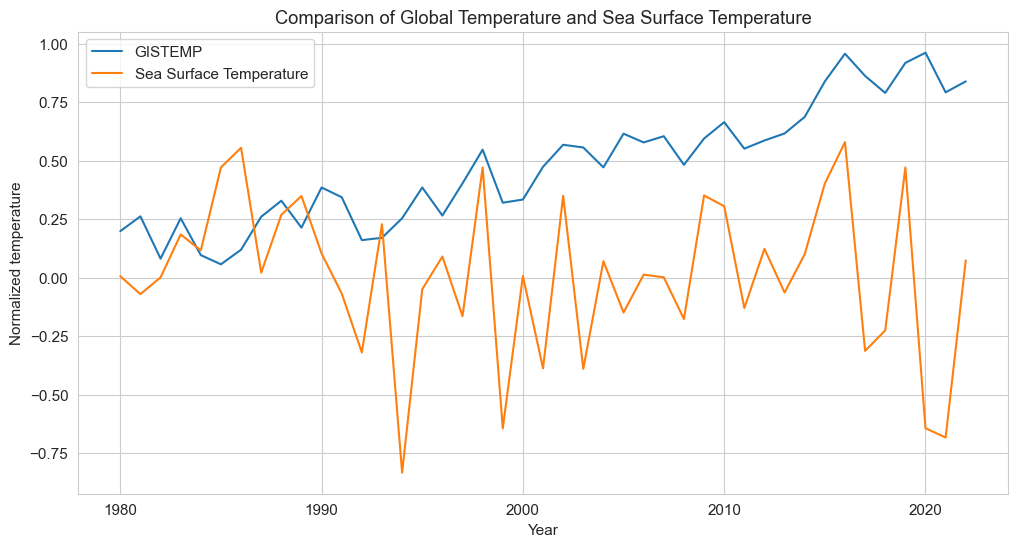

In [31]:
plt.figure(figsize=(12,6))

plt.plot(comparison["year"], comparison["temp_norm"], label="GISTEMP")
plt.plot(comparison["year"], comparison["sst_norm"], label="Sea Surface Temperature")

plt.legend()
plt.title("Comparison of Global Temperature and Sea Surface Temperature")
plt.xlabel("Year")
plt.ylabel("Normalized temperature")

plt.show()

### Comparison of Global Temperature and Sea Surface Temperature

This graph compares global temperature anomalies from the NASA GISTEMP dataset with the yearly average sea surface temperature from an additional climate dataset. Since the second dataset contains multiple observations per year, the sea surface temperature values were first aggregated to annual averages. Both series were then normalized by subtracting their mean values to make their long-term trends easier to compare. The chart shows that both global temperatures and sea surface temperatures follow a similar upward trend over time, reinforcing the evidence that climate change is affecting both the atmosphere and the oceans.

In [32]:
climate[["year","fossil_fuel_consumption","sea_surface_temperature"]].head()

,year,fossil_fuel_consumption,sea_surface_temperature
0,2018,28.14,14.38
1,2008,86.40,15.33
2,1994,34.95,15.90
3,2022,77.11,17.26
4,1987,37.27,16.62


In [33]:
fuel_temp = climate.groupby("year", as_index=False)[
    ["fossil_fuel_consumption","sea_surface_temperature"]
].mean()

In [35]:
fuel_yearly = climate.groupby("year", as_index=False)["fossil_fuel_consumption"].sum()

In [36]:
fuel_sst = pd.merge(
    fuel_yearly,
    sst_yearly,
    on="year",
    how="inner"
)

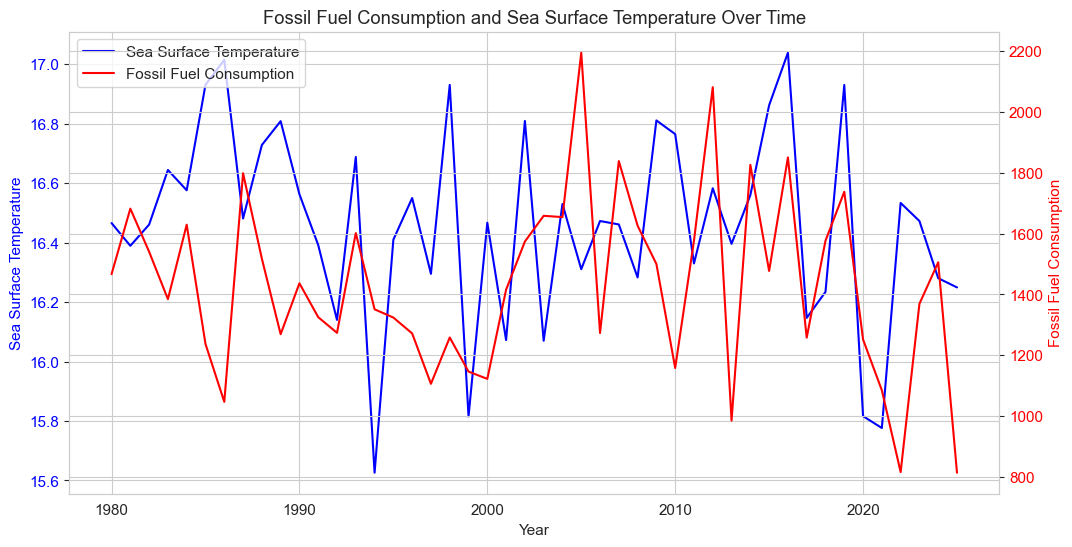

In [39]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Sea surface temperature
line1 = ax1.plot(
    fuel_sst["year"],
    fuel_sst["sea_surface_temperature"],
    color="blue",
    label="Sea Surface Temperature"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Sea Surface Temperature", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# Second axis
ax2 = ax1.twinx()

line2 = ax2.plot(
    fuel_sst["year"],
    fuel_sst["fossil_fuel_consumption"],
    color="red",
    label="Fossil Fuel Consumption"
)

ax2.set_ylabel("Fossil Fuel Consumption", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title("Fossil Fuel Consumption and Sea Surface Temperature Over Time")

plt.show()

In [42]:
yearly = climate.groupby("year", as_index=False).agg({
    "fossil_fuel_consumption": "sum",
    "global_avg_temperature": "mean",
    "sea_surface_temperature": "mean",
    "co2_concentration_ppm": "mean",
    "heatwave_days": "mean"
})

The scatter plot shows only a weak relationship between fossil fuel consumption and global temperature in this dataset. This likely reflects the limited temperature range and synthetic nature of the dataset rather than the absence of a real-world relationship. Time-series analysis and correlations with CO₂ concentrations provide stronger evidence for the connection between human emissions and warming.


In [53]:
yearly = climate.groupby("year", as_index=False).agg({
    "fossil_fuel_consumption": "sum",
    "co2_concentration_ppm": "mean",
    "global_avg_temperature": "mean",
    "sea_surface_temperature": "mean",
    "sea_level_rise_mm": "mean"
})


In [54]:
vars = yearly[[
    "year",
    "fossil_fuel_consumption",
    "co2_concentration_ppm",
    "global_avg_temperature",
    "sea_surface_temperature",
    "sea_level_rise_mm"
]]

In [55]:
normalized = vars.copy()

for col in normalized.columns[1:]:
    normalized[col] = (normalized[col] - normalized[col].mean()) / normalized[col].std()

In [58]:
yearly["fossil_fuel_consumption"].corr(yearly["co2_concentration_ppm"])

np.float64(-0.06964827589672873)

fuel_yearly = climate.groupby("year")["fossil_fuel_consumption"].sum()

In [59]:
temp_yearly = climate.groupby("year")["global_avg_temperature"].mean()

In [61]:
climate["year"] = pd.to_numeric(climate["year"])
climate["fossil_fuel_consumption"] = pd.to_numeric(climate["fossil_fuel_consumption"])
climate["global_avg_temperature"] = pd.to_numeric(climate["global_avg_temperature"])

In [62]:
yearly = climate.groupby("year", as_index=False).agg({
    "fossil_fuel_consumption": "sum",
    "global_avg_temperature": "mean"
})

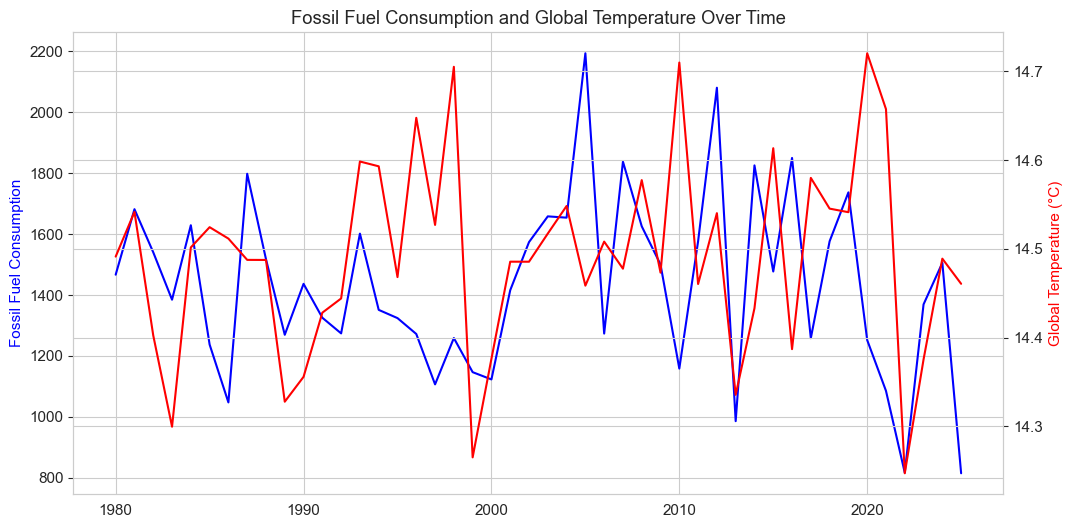

In [64]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(yearly["year"], yearly["fossil_fuel_consumption"], color="blue", label="Fossil Fuel Consumption")
ax1.set_ylabel("Fossil Fuel Consumption", color="blue")

ax2 = ax1.twinx()

ax2.plot(yearly["year"], yearly["global_avg_temperature"], color="red", label="Global Temperature")
ax2.set_ylabel("Global Temperature (°C)", color="red")

plt.title("Fossil Fuel Consumption and Global Temperature Over Time")
plt.xlabel("Year")

plt.show()

In [71]:
yearly["fossil_fuel_consumption"].corr(yearly["global_avg_temperature"])

np.float64(0.09453803339432182)

Although the direct correlation between fossil fuel consumption and global temperature is weak in the dataset, the visualization suggests that some temperature peaks occur shortly after peaks in fossil fuel consumption. This may indicate a delayed relationship between emissions and temperature change. In reality, the climate system does not respond immediately to increases in greenhouse gas emissions because heat is absorbed and redistributed by the oceans and atmosphere over time. As a result, the warming effect of fossil fuel use can appear with a lag, which may partially explain the offset observed between peaks in fossil fuel consumption and subsequent increases in global temperature.

In [73]:
obis = pd.read_csv("../data/raw/occurrence.txt", sep="\t")

In [74]:
obis = pd.read_csv("../data/raw/occurrence.txt", sep="\t")
obis.head()

,id,institutionCode,datasetName,basisOfRecord,occurrenceID,organismQuantity,organismQuantityType,occurrenceStatus,eventID,eventDate,...,minimumDepthInMeters,maximumDepthInMeters,decimalLatitude,decimalLongitude,geodeticDatum,coordinateUncertaintyInMeters,scientificNameID,scientificName,kingdom,taxonRank
0,PRICO_6004_2021-11-02_Acropora_cervicornis_Cor...,NOAA CRCP,"NOAA National Coral Reef Monitoring Program, C...",HumanObservation,PRICO_6004_2021-11-02_Acropora_cervicornis_Cor...,0,Abundance,absent,PRICO_6004_2021-11-02_Coral_demographics,2021-11-02,...,26.212799,29.260799,17.87492,-67.15802,WGS84,20,urn:lsid:marinespecies.org:taxname:206989,Acropora cervicornis,Animalia,Species
1,PRICO_6004_2021-11-02_Acropora_palmata_Coral_d...,NOAA CRCP,"NOAA National Coral Reef Monitoring Program, C...",HumanObservation,PRICO_6004_2021-11-02_Acropora_palmata_Coral_d...,0,Abundance,absent,PRICO_6004_2021-11-02_Coral_demographics,2021-11-02,...,26.212799,29.260799,17.87492,-67.15802,WGS84,20,urn:lsid:marinespecies.org:taxname:288227,Acropora palmata,Animalia,Species
2,PRICO_6004_2021-11-02_Agaricia_agaricites_Cora...,NOAA CRCP,"NOAA National Coral Reef Monitoring Program, C...",HumanObservation,PRICO_6004_2021-11-02_Agaricia_agaricites_Cora...,14,Abundance,present,PRICO_6004_2021-11-02_Coral_demographics,2021-11-02,...,26.212799,29.260799,17.87492,-67.15802,WGS84,20,urn:lsid:marinespecies.org:taxname:287911,Agaricia agaricites,Animalia,Species
3,PRICO_6004_2021-11-02_Agaricia_fragilis_Coral_...,NOAA CRCP,"NOAA National Coral Reef Monitoring Program, C...",HumanObservation,PRICO_6004_2021-11-02_Agaricia_fragilis_Coral_...,0,Abundance,absent,PRICO_6004_2021-11-02_Coral_demographics,2021-11-02,...,26.212799,29.260799,17.87492,-67.15802,WGS84,20,urn:lsid:marinespecies.org:taxname:287912,Agaricia fragilis,Animalia,Species
4,PRICO_6004_2021-11-02_Agaricia_grahamae_Coral_...,NOAA CRCP,"NOAA National Coral Reef Monitoring Program, C...",HumanObservation,PRICO_6004_2021-11-02_Agaricia_grahamae_Coral_...,0,Abundance,absent,PRICO_6004_2021-11-02_Coral_demographics,2021-11-02,...,26.212799,29.260799,17.87492,-67.15802,WGS84,20,urn:lsid:marinespecies.org:taxname:287913,Agaricia grahamae,Animalia,Species


In [79]:
obis["year"] = pd.to_datetime(obis["eventDate"]).dt.year

In [80]:
present = obis[obis["occurrenceStatus"] == "present"]

In [81]:
species_per_year = present.groupby("year")["scientificName"].nunique().reset_index()
species_per_year.columns = ["year", "species_count"]

In [82]:
merged = species_per_year.merge(yearly, on="year")

In [84]:
merged.columns

Index(['year', 'species_count', 'fossil_fuel_consumption',
       'global_avg_temperature'],
      dtype='str')

In [85]:
yearly = climate.groupby("year", as_index=False).agg({
    "sea_surface_temperature": "mean",
    "global_avg_temperature": "mean",
    "fossil_fuel_consumption": "sum"
})

In [86]:
yearly.columns

Index(['year', 'sea_surface_temperature', 'global_avg_temperature',
       'fossil_fuel_consumption'],
      dtype='str')

In [87]:
merged = species_per_year.merge(yearly, on="year")

In [88]:
merged.columns

Index(['year', 'species_count', 'sea_surface_temperature',
       'global_avg_temperature', 'fossil_fuel_consumption'],
      dtype='str')

In [90]:
merged["species_count"].corr(merged["sea_surface_temperature"])

np.float64(0.3657045139753248)

In [91]:
obis["year"] = pd.to_datetime(obis["eventDate"]).dt.year

In [92]:
present = obis[obis["occurrenceStatus"] == "present"]

In [93]:
abundance_per_year = present.groupby("year")["organismQuantity"].sum().reset_index()
abundance_per_year.columns = ["year", "total_coral_abundance"]

In [94]:
merged2 = abundance_per_year.merge(yearly, on="year")

In [96]:
puerto_rico_temp = climate[climate["country"] == "Puerto Rico"]

In [97]:
puerto_rico_temp.head()

,year,country,global_avg_temperature,temperature_anomaly,max_temperature,min_temperature,co2_concentration_ppm,annual_rainfall_mm,sea_level_rise_mm,sea_surface_temperature,...,drought_index,flood_events_count,forest_cover_percent,deforestation_rate,fossil_fuel_consumption,renewable_energy_share,air_quality_index,predicted_temperature_2050,climate_risk_index,sst_norm


In [98]:
climate["country"].unique()

<StringArray>
[  'Germany',     'India',  'Pakistan',       'USA', 'Australia',    'France',
    'Canada',     'China',    'Brazil',        'UK']
Length: 10, dtype: str

In [99]:
puerto_rico_temp = climate[climate["country"] == "USA"]

In [100]:
puerto_rico_temp.head()

,year,country,global_avg_temperature,temperature_anomaly,max_temperature,min_temperature,co2_concentration_ppm,annual_rainfall_mm,sea_level_rise_mm,sea_surface_temperature,...,drought_index,flood_events_count,forest_cover_percent,deforestation_rate,fossil_fuel_consumption,renewable_energy_share,air_quality_index,predicted_temperature_2050,climate_risk_index,sst_norm
3,2022,USA,15.29,1.19,32.17,1.68,415.42,1162.01,3.37,17.26,...,4.29,6,44.34,2.15,77.11,36.65,129,2.51,45.59,0.787617
12,2015,USA,15.37,0.70,27.99,2.78,396.88,1201.52,2.02,18.83,...,3.90,11,44.90,2.73,27.40,8.42,79,2.56,45.24,2.357617
18,2003,USA,14.83,1.44,33.61,7.67,440.49,1189.91,1.98,15.89,...,2.80,7,26.47,1.58,71.99,12.34,157,2.44,71.99,-0.582383
30,2021,USA,13.70,1.14,33.36,6.96,424.83,578.42,2.97,16.16,...,1.35,6,44.67,1.27,73.99,54.80,198,1.76,72.57,-0.312383
46,2005,USA,14.99,0.92,40.02,11.03,423.60,1169.86,3.14,15.44,...,3.91,4,16.85,3.47,52.34,18.40,150,2.01,74.68,-1.032383


In [101]:
pr_yearly = puerto_rico_temp.groupby("year", as_index=False).agg({
    "sea_surface_temperature": "mean"
})

In [102]:
merged_pr = abundance_per_year.merge(pr_yearly, on="year")

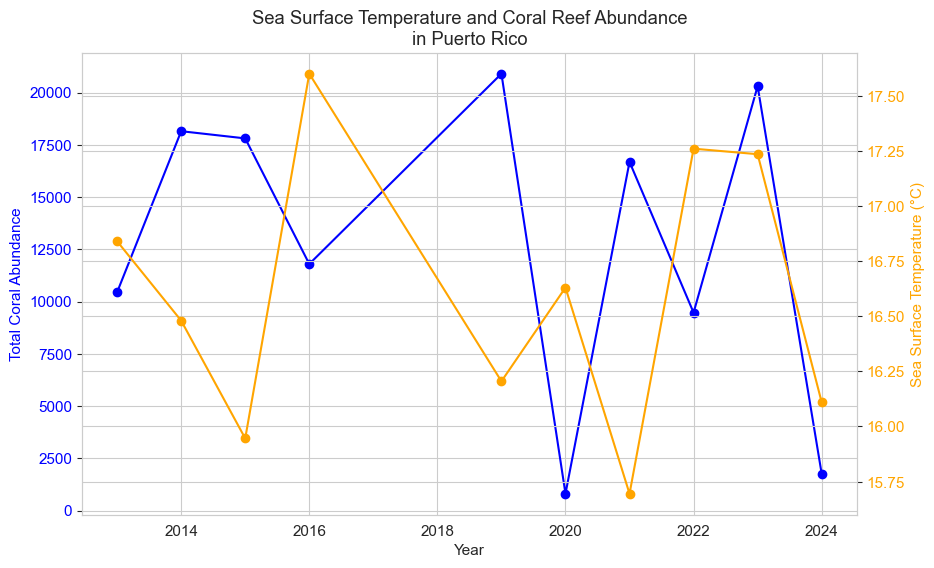

In [108]:
fig, ax1 = plt.subplots(figsize=(10,6))

# Coral abundance (left axis)
ax1.plot(
    merged_pr["year"],
    merged_pr["total_coral_abundance"],
    marker="o",
    color="blue",
    label="Coral Abundance"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Total Coral Abundance", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# Temperature (right axis)
ax2 = ax1.twinx()

ax2.plot(
    merged_pr["year"],
    merged_pr["sea_surface_temperature"],
    marker="o",
    color="orange",
    label="Sea Surface Temperature"
)

ax2.set_ylabel("Sea Surface Temperature (°C)", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

plt.title("Sea Surface Temperature and Coral Reef Abundance\nin Puerto Rico")

plt.show()

In [109]:
bleaching = pd.read_csv("../data/raw/realistic_ocean_climate_dataset_raw 2.csv")

bleaching.head()

,Date,Location,Latitude,Longitude,SST (°C),pH Level,Bleaching Severity,Species Observed,Marine Heatwave
0,2015-01-01,Red Sea,20.0248,38.4931,29.47,8.107,NaN,106,False
1,2015-01-07,Great Barrier Reef,-18.2988,147.7782,29.65,8.004,High,116,False
2,2015-01-14,Caribbean Sea,14.9768,-75.0233,28.86,7.947,High,90,False
3,2015-01-20,Great Barrier Reef,-18.3152,147.6486,28.97,7.995,Medium,94,False
4,2015-01-27,Galápagos,-0.8805,-90.9769,28.60,7.977,NaN,110,False


In [110]:
bleaching.columns

Index(['Date', 'Location', 'Latitude', 'Longitude', 'SST (°C)', 'pH Level',
       'Bleaching Severity', 'Species Observed', 'Marine Heatwave'],
      dtype='str')

In [113]:
bleaching["Bleaching Severity"].unique()

<StringArray>
[nan, 'High', 'Medium', 'Low']
Length: 4, dtype: str

In [114]:
severity_map = {
    "Low": 1,
    "Medium": 2,
    "High": 3
}

bleaching["bleaching_severity_numeric"] = bleaching["Bleaching Severity"].map(severity_map)

In [115]:
bleaching[["Bleaching Severity", "bleaching_severity_numeric"]].head()

,Bleaching Severity,bleaching_severity_numeric
0,NaN,NaN
1,High,3.0
2,High,3.0
3,Medium,2.0
4,NaN,NaN


In [116]:
bleaching[["Bleaching Severity", "bleaching_severity_numeric"]].head()

,Bleaching Severity,bleaching_severity_numeric
0,NaN,NaN
1,High,3.0
2,High,3.0
3,Medium,2.0
4,NaN,NaN


In [117]:
bleaching_yearly = (
    bleaching.groupby("year", as_index=False)["bleaching_severity_numeric"]
    .mean()
)

bleaching_yearly.head()

,year,bleaching_severity_numeric
0,2015,1.925000
1,2016,1.694444
2,2017,2.000000
3,2018,1.771429
4,2019,2.024390


In [119]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__session__', '_i', '_ii', '_iii', '_i1', 'pd', 'plt', '_i2', '_i3', '_i4', 'sns', '_i5', '_i6', '_i7', 'f', 'i', '_i8', 'Path', 'DATA_DIR', 'load_badc_csv', '_i9', 'gistemp', 'noaa', 'hadcrut', 'berkeley', 'era5', 'jra55', '_i10', '_10', '_i11', '_i12', '_i13', '_i14', 'recent', '_i15', '_i16', '_i17', '_i18', '_i19', '_i20', 'climate', '_20', '_i21', '_21', '_i22', '_i23', '_23', '_i24', '_i25', '_i26', 'merged', '_26', '_i27', 'sst_yearly', '_i28', '_i29', '_i30', 'comparison', '_30', '_i31', '_i32', '_32', '_i33', 'fuel_temp', '_i34', '_i35', 'fuel_yearly', '_i36', 'fuel_sst', '_i37', '_i38', 'fig', 'ax1', 'ax2', '_i39', 'line1', 'line2', 'lines', 'labels', '_i40', '_i41', '_i42', 'yearly', '_i43', '_i44', '_i45', '_i46', '_i47', '_i48', '_i49', '_i50', '_i51', '_i52', '_i53', '_i54', 'v

In [120]:
climate.columns

Index(['year', 'country', 'global_avg_temperature', 'temperature_anomaly',
       'max_temperature', 'min_temperature', 'co2_concentration_ppm',
       'annual_rainfall_mm', 'sea_level_rise_mm', 'sea_surface_temperature',
       'heatwave_days', 'drought_index', 'flood_events_count',
       'forest_cover_percent', 'deforestation_rate', 'fossil_fuel_consumption',
       'renewable_energy_share', 'air_quality_index',
       'predicted_temperature_2050', 'climate_risk_index', 'sst_norm'],
      dtype='str')

In [121]:
co2_world = climate[["year", "co2_concentration_ppm"]]

In [122]:
merged_bleaching_co2 = bleaching_yearly.merge(co2_world, on="year")

/Users/goncalotrindade/Desktop/git-practice/project-3/first_project/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


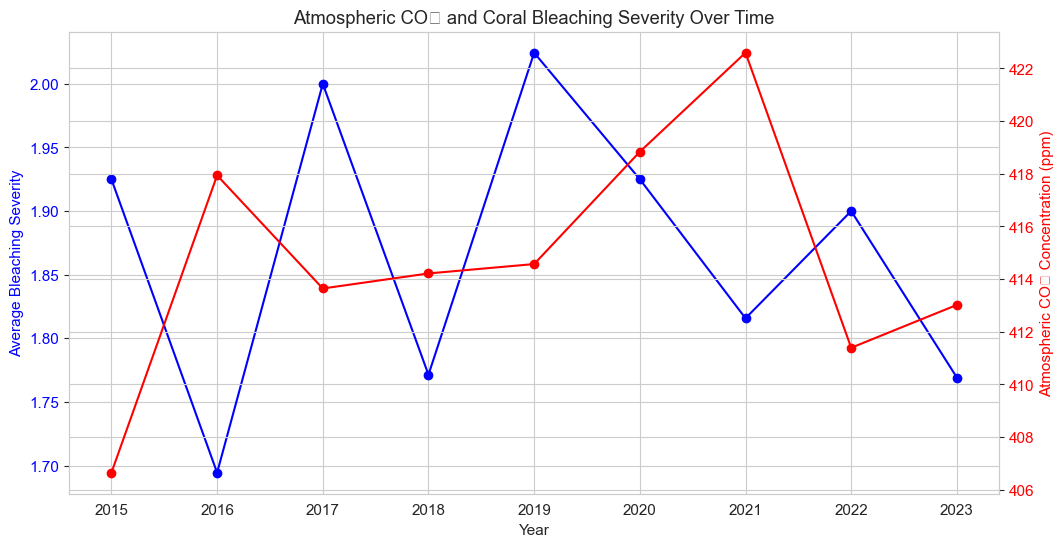

In [124]:
# yearly bleaching severity
bleaching["year"] = pd.to_datetime(bleaching["Date"]).dt.year

severity_map = {
    "Low": 1,
    "Medium": 2,
    "High": 3
}

bleaching["bleaching_severity_numeric"] = bleaching["Bleaching Severity"].map(severity_map)

bleaching_yearly = (
    bleaching.groupby("year", as_index=False)["bleaching_severity_numeric"]
    .mean()
)

# yearly CO2
co2_yearly = climate.groupby("year", as_index=False)["co2_concentration_ppm"].mean()

# merge
merged_bleaching_co2 = bleaching_yearly.merge(co2_yearly, on="year")

# plot with two axes
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(
    merged_bleaching_co2["year"],
    merged_bleaching_co2["bleaching_severity_numeric"],
    marker="o",
    color="blue",
    label="Average Bleaching Severity"
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Average Bleaching Severity", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

ax2 = ax1.twinx()
ax2.plot(
    merged_bleaching_co2["year"],
    merged_bleaching_co2["co2_concentration_ppm"],
    marker="o",
    color="red",
    label="CO₂ Concentration"
)
ax2.set_ylabel("Atmospheric CO₂ Concentration (ppm)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Atmospheric CO₂ and Coral Bleaching Severity Over Time")
plt.show()

Atmospheric CO₂ concentration shows a clear upward trend during the observed period. However, coral bleaching severity fluctuates from year to year and does not show a direct linear relationship with CO₂ concentration in this dataset. This may reflect the complexity of marine ecosystems and the delayed effects of climate forcing. Coral bleaching is typically triggered by marine heatwaves and sea surface temperature anomalies, which are themselves influenced by CO₂-driven climate change but may occur with temporal lag.


In [128]:
df = pd.read_csv("../data/raw/tas_NOAAGlobalTemp.csv", skiprows=8)

In [129]:
df.columns

Index(['location', 'G', '90.', '-180.', '-90.', '180.'], dtype='str')

In [131]:
with open("../data/raw/tas_NOAAGlobalTemp.csv", "r") as f:
    for i in range(20):
        print(f.readline())

Conventions,G,BADC-CSV,1

title,G,Global mean temperature

last_revised_date,G,2023-03-03

date_valid,G,2023-03-03

feature_type,G,area average

creator,G,WMO

source,G,Produced by climind version 0.1

observation_station,G,derived data

location,G,90.,-180.,-90.,180.

activity,G,WMO

history,G,"Data set created from file ['aravg.mon.land_ocean.90S.90N.v5.0.0.202212.asc', 'aravg.ann.land_ocean.90S.90N.*.asc'] downloaded from ['https://www.ncei.noaa.gov/data/noaa-global-surface-temperature/v5/access/timeseries/aravg.mon.land_ocean.90S.90N.v5.0.0.202212.asc', 'https://www.ncei.noaa.gov/data/noaa-global-surface-temperature/v5/access/timeseries/aravg.ann.land_ocean.90S.90N.*.asc'] at ['2023-02-27 09:18:13']"

history,G,"Rebaselined to 1981-2010 for each month separately by calculating the arithmetic mean of the data over the baseline period and subtracting the mean from all data values. This is done for each month separately (Januarys, Februarys etc)."

history,G,"Calculated annual average

In [132]:
with open("../data/raw/tas_NOAAGlobalTemp.csv", "r") as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    if line.strip().lower() == "data":
        print("data starts after line:", i)
    if line.strip().lower() == "end_data":
        print("data ends at line:", i)

data starts after line: 28


In [133]:
df = pd.read_csv("../data/raw/tas_NOAAGlobalTemp.csv", skiprows=29)
df.head()

,time,year,data
0,29219,1880.0,0.1321
1,29585,1881.0,0.1702
2,29950,1882.0,0.1561
3,30315,1883.0,0.0728
4,30680,1884.0,-0.0136


In [134]:
df.columns
df.tail()

,time,year,data
139,79988,2019.0,1.1936
140,80353,2020.0,1.2275
141,80719,2021.0,1.0922
142,81084,2022.0,1.1057
143,end data,NaN,NaN


In [135]:
df = df[df["year"].notna()]

In [136]:
df["year"] = df["year"].astype(int)

In [137]:
df.tail()

,time,year,data
138,79623,2018,1.0697
139,79988,2019,1.1936
140,80353,2020,1.2275
141,80719,2021,1.0922
142,81084,2022,1.1057


In [138]:
temp_2015 = df[df["year"] == 2015]["data"].values[0]
temp_2022 = df[df["year"] == 2022]["data"].values[0]

print(temp_2015)
print(temp_2022)

1.1749
1.1057


In [139]:
increase = temp_2022 - temp_2015
percentage_increase = (increase / abs(temp_2015)) * 100

print("Increase:", increase)
print("Percentage increase:", percentage_increase)

Increase: -0.06920000000000015
Percentage increase: -5.889862967061039


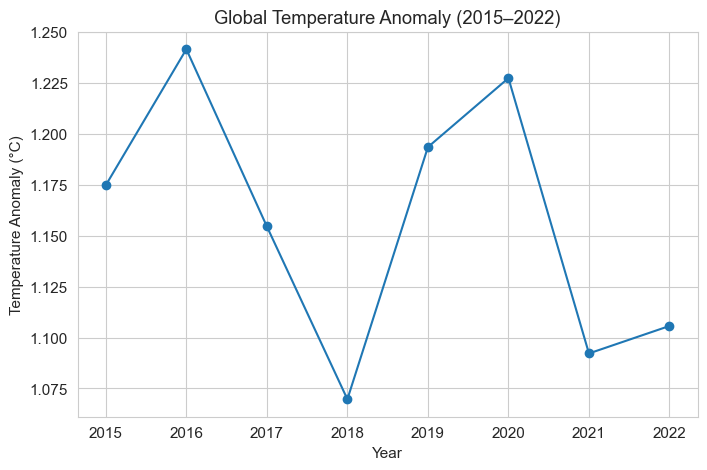

In [140]:
import matplotlib.pyplot as plt

subset = df[(df["year"] >= 2015) & (df["year"] <= 2022)]

plt.figure(figsize=(8,5))
plt.plot(subset["year"], subset["data"], marker="o")

plt.title("Global Temperature Anomaly (2015–2022)")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid(True)

plt.show()

In [146]:
with open("../data/raw/tas_ERA5.csv", "r") as f:
    for i in range(20):
        print(f.readline())

Conventions,G,BADC-CSV,1

title,G,Global mean temperature

last_revised_date,G,2023-03-03

date_valid,G,2023-03-03

feature_type,G,area average

creator,G,WMO

source,G,Produced by climind version 0.1

observation_station,G,derived data

location,G,90.,-180.,-90.,180.

activity,G,WMO

history,G,"Data set created from file ['era5_monthy_sfc_temp_ano_global_1958-2022_for_wmo.csv'] downloaded from ['era5_monthy_sfc_temp_ano_global_1958-2022_for_wmo.csv'] at ['2023-02-09 16:00:54']"

history,G,"Rebaselined to 1981-2010 for each month separately by calculating the arithmetic mean of the data over the baseline period and subtracting the mean from all data values. This is done for each month separately (Januarys, Februarys etc)."

history,G,"Calculated annual average from monthly averages using arithmetic mean"

history,G,"Selected years within the range 1850 to 2022."

history,G,"Added offset of 0.69 to all data values."

history,G,"Manually changed baseline to 1850-1900. Note that data valu

In [148]:
climate_df = pd.read_csv("../data/raw/realistic_ocean_climate_dataset.csv")
climate_df.head()

,Date,Location,Latitude,Longitude,SST (°C),pH Level,Bleaching Severity,Species Observed,Marine Heatwave
0,2015-01-01,Red Sea,20.0248,38.4931,29.47,8.107,NaN,106,False
1,2015-01-07,Great Barrier Reef,-18.2988,147.7782,29.65,8.004,High,116,False
2,2015-01-14,Caribbean Sea,14.9768,-75.0233,28.86,7.947,High,90,False
3,2015-01-20,Great Barrier Reef,-18.3152,147.6486,28.97,7.995,Medium,94,False
4,2015-01-27,Galápagos,-0.8805,-90.9769,28.60,7.977,NaN,110,False


In [150]:
climate_df.columns

Index(['Date', 'Location', 'Latitude', 'Longitude', 'SST (°C)', 'pH Level',
       'Bleaching Severity', 'Species Observed', 'Marine Heatwave'],
      dtype='str')

In [151]:
climate.columns

Index(['year', 'country', 'global_avg_temperature', 'temperature_anomaly',
       'max_temperature', 'min_temperature', 'co2_concentration_ppm',
       'annual_rainfall_mm', 'sea_level_rise_mm', 'sea_surface_temperature',
       'heatwave_days', 'drought_index', 'flood_events_count',
       'forest_cover_percent', 'deforestation_rate', 'fossil_fuel_consumption',
       'renewable_energy_share', 'air_quality_index',
       'predicted_temperature_2050', 'climate_risk_index', 'sst_norm'],
      dtype='str')

In [153]:
global_df = climate[climate["country"] == "Global"]

In [154]:
climate["country"].unique()

<StringArray>
[  'Germany',     'India',  'Pakistan',       'USA', 'Australia',    'France',
    'Canada',     'China',    'Brazil',        'UK']
Length: 10, dtype: str

In [156]:
global_df = climate.groupby("year")["global_avg_temperature"].mean().reset_index()

In [157]:
global_df.head()

,year,global_avg_temperature
0,1980,14.491290
1,1981,14.541667
2,1982,14.402400
3,1983,14.299565
4,1984,14.501613


In [158]:
temp_2015 = global_df[global_df["year"] == 2015]["global_avg_temperature"].values[0]
temp_2025 = global_df[global_df["year"] == 2025]["global_avg_temperature"].values[0]

percentage_increase = ((temp_2025 - temp_2015) / temp_2015) * 100

print(temp_2015, temp_2025, percentage_increase)

14.61344827586207 14.460625 -1.0457714905967574


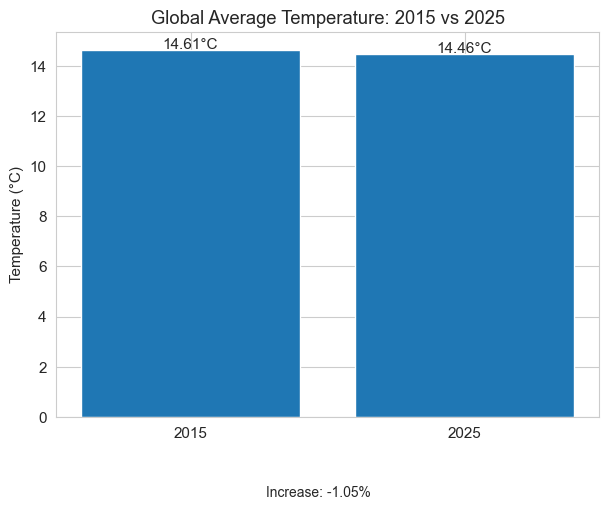

In [159]:
import matplotlib.pyplot as plt

values = [temp_2015, temp_2025]
labels = ["2015", "2025"]

plt.figure(figsize=(7,5))
bars = plt.bar(labels, values)

plt.title("Global Average Temperature: 2015 vs 2025")
plt.ylabel("Temperature (°C)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.05,
        f"{height:.2f}°C",
        ha="center"
    )

plt.figtext(
    0.5,
    -0.05,
    f"Increase: {percentage_increase:.2f}%",
    ha="center",
    fontsize=10
)

plt.show()

In [160]:
climate["year"].max()

np.int64(2025)

In [161]:
climate.shape

(1200, 21)

In [163]:
climate.head()

,year,country,global_avg_temperature,temperature_anomaly,max_temperature,min_temperature,co2_concentration_ppm,annual_rainfall_mm,sea_level_rise_mm,sea_surface_temperature,...,drought_index,flood_events_count,forest_cover_percent,deforestation_rate,fossil_fuel_consumption,renewable_energy_share,air_quality_index,predicted_temperature_2050,climate_risk_index,sst_norm
0,2018,Germany,14.03,1.16,37.02,4.31,387.85,814.11,2.14,14.38,...,0.85,11,64.33,1.26,28.14,42.30,148,3.30,23.69,-2.092383
1,2008,India,15.03,1.05,32.25,-0.44,407.24,735.61,4.19,15.33,...,1.01,11,42.69,0.62,86.40,53.65,50,2.63,70.10,-1.142383
2,1994,Pakistan,14.86,1.24,41.57,1.08,450.54,1982.92,6.46,15.90,...,4.59,1,65.47,2.08,34.95,47.20,107,1.33,34.74,-0.572383
3,2022,USA,15.29,1.19,32.17,1.68,415.42,1162.01,3.37,17.26,...,4.29,6,44.34,2.15,77.11,36.65,129,2.51,45.59,0.787617
4,1987,Australia,13.75,1.32,40.99,10.38,403.42,1170.25,4.64,16.62,...,1.00,4,14.18,0.76,37.27,50.35,149,2.87,55.77,0.147617


In [164]:
climate.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   year                        1200 non-null   int64  
 1   country                     1200 non-null   str    
 2   global_avg_temperature      1200 non-null   float64
 3   temperature_anomaly         1200 non-null   float64
 4   max_temperature             1200 non-null   float64
 5   min_temperature             1200 non-null   float64
 6   co2_concentration_ppm       1200 non-null   float64
 7   annual_rainfall_mm          1200 non-null   float64
 8   sea_level_rise_mm           1200 non-null   float64
 9   sea_surface_temperature     1200 non-null   float64
 10  heatwave_days               1200 non-null   int64  
 11  drought_index               1200 non-null   float64
 12  flood_events_count          1200 non-null   int64  
 13  forest_cover_percent        1200 non-null   

In [165]:
climate.isna().sum()

year                          0
country                       0
global_avg_temperature        0
temperature_anomaly           0
max_temperature               0
min_temperature               0
co2_concentration_ppm         0
annual_rainfall_mm            0
sea_level_rise_mm             0
sea_surface_temperature       0
heatwave_days                 0
drought_index                 0
flood_events_count            0
forest_cover_percent          0
deforestation_rate            0
fossil_fuel_consumption       0
renewable_energy_share        0
air_quality_index             0
predicted_temperature_2050    0
climate_risk_index            0
sst_norm                      0
dtype: int64

In [167]:
climate.duplicated().sum()

np.int64(0)

In [168]:
climate[["year", "country", "global_avg_temperature"]].head(20)

,year,country,global_avg_temperature
0,2018,Germany,14.03
1,2008,India,15.03
2,1994,Pakistan,14.86
3,2022,USA,15.29
4,1987,Australia,13.75
5,2000,France,14.20
6,2018,France,14.67
7,1998,India,13.94
8,2002,Canada,14.89
9,1990,Canada,15.23


In [169]:
sorted(climate["year"].unique())

[np.int64(1980),
 np.int64(1981),
 np.int64(1982),
 np.int64(1983),
 np.int64(1984),
 np.int64(1985),
 np.int64(1986),
 np.int64(1987),
 np.int64(1988),
 np.int64(1989),
 np.int64(1990),
 np.int64(1991),
 np.int64(1992),
 np.int64(1993),
 np.int64(1994),
 np.int64(1995),
 np.int64(1996),
 np.int64(1997),
 np.int64(1998),
 np.int64(1999),
 np.int64(2000),
 np.int64(2001),
 np.int64(2002),
 np.int64(2003),
 np.int64(2004),
 np.int64(2005),
 np.int64(2006),
 np.int64(2007),
 np.int64(2008),
 np.int64(2009),
 np.int64(2010),
 np.int64(2011),
 np.int64(2012),
 np.int64(2013),
 np.int64(2014),
 np.int64(2015),
 np.int64(2016),
 np.int64(2017),
 np.int64(2018),
 np.int64(2019),
 np.int64(2020),
 np.int64(2021),
 np.int64(2022),
 np.int64(2023),
 np.int64(2024),
 np.int64(2025)]

In [170]:
climate["country"].unique()

<StringArray>
[  'Germany',     'India',  'Pakistan',       'USA', 'Australia',    'France',
    'Canada',     'China',    'Brazil',        'UK']
Length: 10, dtype: str

In [171]:
climate["year"].dtype

dtype('int64')

In [172]:
climate["global_avg_temperature"].dtype

dtype('float64')

In [173]:
climate["year"] = pd.to_numeric(climate["year"], errors="coerce")
climate["global_avg_temperature"] = pd.to_numeric(climate["global_avg_temperature"], errors="coerce")

In [174]:
climate.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   year                        1200 non-null   int64  
 1   country                     1200 non-null   str    
 2   global_avg_temperature      1200 non-null   float64
 3   temperature_anomaly         1200 non-null   float64
 4   max_temperature             1200 non-null   float64
 5   min_temperature             1200 non-null   float64
 6   co2_concentration_ppm       1200 non-null   float64
 7   annual_rainfall_mm          1200 non-null   float64
 8   sea_level_rise_mm           1200 non-null   float64
 9   sea_surface_temperature     1200 non-null   float64
 10  heatwave_days               1200 non-null   int64  
 11  drought_index               1200 non-null   float64
 12  flood_events_count          1200 non-null   int64  
 13  forest_cover_percent        1200 non-null   

In [175]:
climate["global_avg_temperature"].describe()

count    1200.000000
mean       14.492850
std         0.594588
min        12.420000
25%        14.080000
50%        14.510000
75%        14.910000
max        16.140000
Name: global_avg_temperature, dtype: float64

In [176]:
climate.sort_values("global_avg_temperature").head(10)

,year,country,global_avg_temperature,temperature_anomaly,max_temperature,min_temperature,co2_concentration_ppm,annual_rainfall_mm,sea_level_rise_mm,sea_surface_temperature,...,drought_index,flood_events_count,forest_cover_percent,deforestation_rate,fossil_fuel_consumption,renewable_energy_share,air_quality_index,predicted_temperature_2050,climate_risk_index,sst_norm
841,2005,Australia,12.42,1.18,35.62,7.51,422.95,1007.27,3.79,16.75,...,1.16,9,31.97,3.29,27.89,37.61,149,3.19,17.77,0.277617
144,1983,Australia,12.78,1.03,36.67,7.53,454.34,1417.10,3.70,18.96,...,3.38,12,25.20,3.09,86.62,5.19,148,2.16,71.19,2.487617
668,2011,Pakistan,12.80,1.09,28.82,10.14,417.23,1426.19,4.86,17.45,...,2.33,0,33.44,0.56,40.24,27.24,163,1.77,13.90,0.977617
108,2007,Canada,12.84,0.62,38.76,6.93,425.07,738.81,4.81,18.57,...,3.40,3,44.69,3.41,65.08,28.47,170,2.27,86.91,2.097617
1144,2014,Canada,12.89,0.53,40.12,6.26,416.65,790.16,4.41,15.89,...,2.91,6,13.68,0.21,41.34,14.86,61,2.37,46.17,-0.582383
701,1989,Brazil,12.92,2.01,28.69,7.20,395.95,1318.83,5.81,16.73,...,3.63,8,32.64,2.31,67.10,32.20,142,0.97,72.37,0.257617
863,1986,Canada,12.96,1.81,42.82,12.07,428.91,761.37,2.51,18.08,...,4.92,13,11.81,1.46,37.91,47.84,54,2.21,83.63,1.607617
547,2009,Australia,13.05,0.64,31.14,2.04,402.62,855.20,2.16,17.31,...,4.39,13,65.82,2.56,67.12,49.72,117,2.44,15.24,0.837617
703,2024,Brazil,13.05,0.59,37.08,2.79,428.54,555.47,4.13,16.93,...,3.91,0,62.69,1.36,53.34,24.25,95,1.90,50.51,0.457617
377,2015,France,13.06,0.98,37.81,5.08,383.94,473.39,3.20,18.50,...,0.04,6,55.79,1.80,31.32,29.81,163,1.84,16.63,2.027617


In [177]:
climate.sort_values("global_avg_temperature", ascending=False).head(10)

,year,country,global_avg_temperature,temperature_anomaly,max_temperature,min_temperature,co2_concentration_ppm,annual_rainfall_mm,sea_level_rise_mm,sea_surface_temperature,...,drought_index,flood_events_count,forest_cover_percent,deforestation_rate,fossil_fuel_consumption,renewable_energy_share,air_quality_index,predicted_temperature_2050,climate_risk_index,sst_norm
399,1994,Germany,16.14,1.28,26.79,5.79,456.13,753.30,7.75,14.25,...,4.01,8,68.69,3.15,63.71,58.55,160,1.96,63.54,-2.222383
548,1996,Australia,16.13,1.31,32.50,9.22,402.82,786.50,3.20,17.84,...,1.42,3,43.26,2.92,22.86,47.17,118,1.61,41.10,1.367617
361,1981,Australia,16.11,1.30,39.91,3.69,420.52,573.56,4.10,16.49,...,1.36,11,40.58,2.61,45.79,45.29,103,1.60,57.08,0.017617
444,2005,Germany,16.11,1.24,25.56,13.00,424.43,1176.85,2.68,16.09,...,2.23,12,67.77,0.57,35.03,45.03,70,2.36,93.10,-0.382383
189,1994,Australia,16.10,1.42,43.52,10.76,417.07,1168.58,4.88,15.80,...,2.51,4,30.47,3.30,41.54,17.32,88,2.62,87.53,-0.672383
833,2005,France,16.08,0.88,28.13,12.46,346.85,1603.08,4.08,16.99,...,2.13,13,24.75,3.45,61.60,6.40,180,2.28,51.96,0.517617
179,2018,India,15.95,1.09,39.10,5.91,401.88,292.69,3.14,14.80,...,3.42,9,15.06,0.50,47.63,46.89,118,2.63,50.70,-1.672383
519,1983,China,15.90,0.99,46.39,-0.56,416.59,646.40,3.16,14.73,...,1.05,5,29.96,1.46,74.09,48.91,80,2.18,30.51,-1.742383
558,1991,India,15.90,0.95,32.97,13.07,416.99,1055.04,5.25,15.56,...,2.32,1,11.44,0.70,63.21,12.63,46,1.87,64.86,-0.912383
52,1987,China,15.88,0.61,33.77,6.72,465.88,1120.25,1.86,16.44,...,4.79,14,34.17,1.36,56.21,25.27,107,1.77,66.93,-0.032383


In [178]:
climate.groupby("year")["country"].nunique()

year
1980    10
1981     9
1982     9
1983    10
1984     9
1985    10
1986     8
1987    10
1988     9
1989    10
1990    10
1991     9
1992     9
1993     9
1994    10
1995     8
1996    10
1997     9
1998    10
1999    10
2000     9
2001     8
2002    10
2003     8
2004     8
2005    10
2006    10
2007    10
2008     9
2009    10
2010     9
2011     9
2012    10
2013     9
2014    10
2015     9
2016    10
2017     9
2018     9
2019    10
2020     9
2021     9
2022    10
2023     9
2024    10
2025     9
Name: country, dtype: int64

In [179]:
global_temp = climate.groupby("year")["global_avg_temperature"].mean().reset_index()

global_temp.head()

,year,global_avg_temperature
0,1980,14.491290
1,1981,14.541667
2,1982,14.402400
3,1983,14.299565
4,1984,14.501613


In [180]:
temp_2015 = global_temp[global_temp["year"] == 2015]["global_avg_temperature"].values[0]
temp_2025 = global_temp[global_temp["year"] == 2025]["global_avg_temperature"].values[0]

percentage_increase = ((temp_2025 - temp_2015) / temp_2015) * 100

print(temp_2015, temp_2025, percentage_increase)

14.61344827586207 14.460625 -1.0457714905967574


In [184]:
import pandas as pd

df = pd.read_csv("../data/raw/Nasa global warming.csv", skiprows=1)

df.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.19,-.25,-.10,-.17,-.11,-.22,-.19,-.11,-.15,-.24,-.23,-.18,-.18,***,***,-.13,-.17,-.21
1,1881,-0.21,-.15,.02,.04,.05,-.20,-.01,-.04,-.16,-.22,-.19,-.08,-.10,-.10,-.18,.04,-.08,-.19
2,1882,0.15,.13,.04,-.18,-.15,-.24,-.17,-.08,-.15,-.24,-.17,-.37,-.12,-.09,.07,-.10,-.16,-.19
3,1883,-0.30,-.37,-.13,-.19,-.18,-.07,-.08,-.14,-.22,-.11,-.25,-.12,-.18,-.20,-.35,-.17,-.10,-.19
4,1884,-0.14,-.09,-.37,-.40,-.34,-.35,-.31,-.28,-.27,-.25,-.34,-.31,-.29,-.27,-.11,-.37,-.31,-.29


In [185]:
df.columns

Index(['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
       'Oct', 'Nov', 'Dec', 'J-D', 'D-N', 'DJF', 'MAM', 'JJA', 'SON'],
      dtype='str')

In [186]:
temp_df = df[["Year", "J-D"]]

temp_df.head()

,Year,J-D
0,1880,-.18
1,1881,-.10
2,1882,-.12
3,1883,-.18
4,1884,-.29


In [187]:
temp_df = temp_df.rename(columns={
    "Year": "year",
    "J-D": "temp_anomaly"
})

In [188]:
temp_recent = temp_df[(temp_df["year"] >= 2015) & (temp_df["year"] <= 2025)]

temp_recent

,year,temp_anomaly
135,2015,.90
136,2016,1.01
137,2017,.92
138,2018,.85
139,2019,.98
140,2020,1.01
141,2021,.85
142,2022,.90
143,2023,1.17
144,2024,1.28


In [190]:
temp_recent["temp_anomaly"] = pd.to_numeric(temp_recent["temp_anomaly"], errors="coerce")

In [191]:
temp_2015 = temp_recent[temp_recent["year"] == 2015]["temp_anomaly"].values[0]
temp_2025 = temp_recent[temp_recent["year"] == 2025]["temp_anomaly"].values[0]

increase = temp_2025 - temp_2015

print("2015:", temp_2015)
print("2025:", temp_2025)
print("Increase:", increase)

2015: 0.9
2025: 1.19
Increase: 0.2899999999999999


In [192]:
percentage_increase = ((temp_2025 - temp_2015) / temp_2015) * 100

print("Percentage increase:", percentage_increase)

Percentage increase: 32.222222222222214


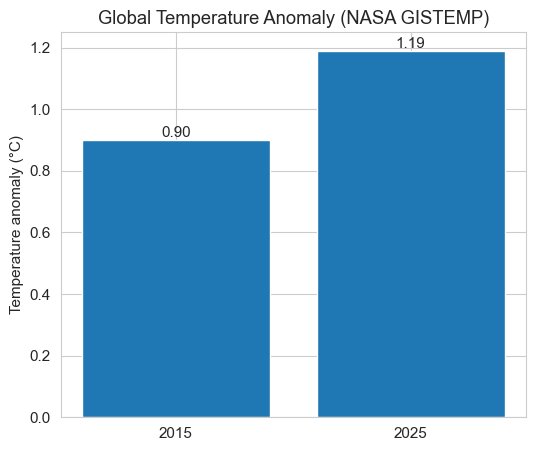

In [193]:
import matplotlib.pyplot as plt

labels = ["2015", "2025"]
values = [temp_2015, temp_2025]

plt.figure(figsize=(6,5))
bars = plt.bar(labels, values)

plt.title("Global Temperature Anomaly (NASA GISTEMP)")
plt.ylabel("Temperature anomaly (°C)")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.2f}",
             ha='center', va='bottom')

plt.show()

In [194]:
percentage_increase = ((temp_2025 - temp_2015) / temp_2015) * 100

print(f"Percentage increase from 2015 to 2025: {percentage_increase:.2f}%")

Percentage increase from 2015 to 2025: 32.22%


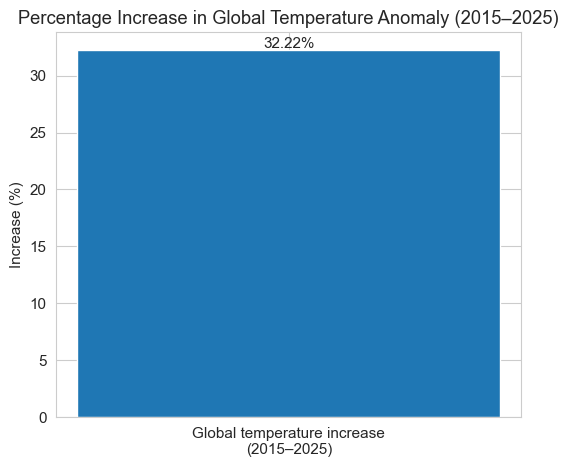

In [195]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.bar(["Global temperature increase\n(2015–2025)"], [percentage_increase])

plt.ylabel("Increase (%)")
plt.title("Percentage Increase in Global Temperature Anomaly (2015–2025)")

plt.text(0, percentage_increase, f"{percentage_increase:.2f}%",
         ha="center", va="bottom")

plt.show()

In [196]:
percentage_increase = ((temp_2025 - temp_2015) / temp_2015) * 100

percentage_df = pd.DataFrame({
    "metric": ["Global temperature anomaly increase"],
    "start_year": [2015],
    "end_year": [2025],
    "temp_2015_C": [temp_2015],
    "temp_2025_C": [temp_2025],
    "increase_C": [temp_2025 - temp_2015],
    "increase_percent": [percentage_increase]
})

percentage_df

,metric,start_year,end_year,temp_2015_C,temp_2025_C,increase_C,increase_percent
0,Global temperature anomaly increase,2015,2025,0.9,1.19,0.29,32.222222


In [197]:
last_three_years = temp_df.sort_values("year").tail(3)

last_three_years

,year,temp_anomaly
144,2024,1.28
145,2025,1.19
146,2026,***


In [198]:
last_four_years = temp_df.sort_values("year").tail(4).reset_index(drop=True)

last_four_years

,year,temp_anomaly
0,2023,1.17
1,2024,1.28
2,2025,1.19
3,2026,***


In [200]:
temp_df["temp_anomaly"] = pd.to_numeric(temp_df["temp_anomaly"], errors="coerce")

In [201]:
temp_df["global_avg_temp_C"] = 14 + temp_df["temp_anomaly"]

In [202]:
temp_df.head()

,year,temp_anomaly,global_avg_temp_C
0,1880,-0.18,13.82
1,1881,-0.10,13.90
2,1882,-0.12,13.88
3,1883,-0.18,13.82
4,1884,-0.29,13.71


In [203]:
last_four_years = temp_df.sort_values("year").tail(4)

last_four_years[["year", "global_avg_temp_C"]]

,year,global_avg_temp_C
143,2023,15.17
144,2024,15.28
145,2025,15.19
146,2026,NaN


In [204]:
temp_2015 = temp_df[temp_df["year"] == 2015]["global_avg_temp_C"].values[0]
temp_2025 = temp_df[temp_df["year"] == 2025]["global_avg_temp_C"].values[0]

In [205]:
percentage_increase = ((temp_2025 - temp_2015) / temp_2015) * 100

In [206]:
chart_df = pd.DataFrame({
    "metric": ["Temperature 2015", "Temperature 2025", "Increase (%)"],
    "value": [temp_2015, temp_2025, percentage_increase]
})

chart_df

,metric,value
0,Temperature 2015,14.900000
1,Temperature 2025,15.190000
2,Increase (%),1.946309


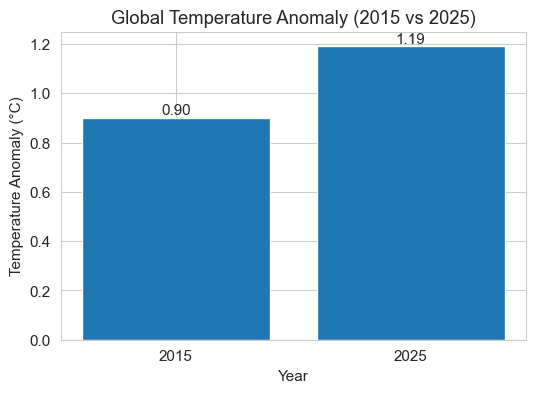

In [207]:
import matplotlib.pyplot as plt

# select years
anomaly_df = temp_df[temp_df["year"].isin([2015, 2025])]

plt.figure(figsize=(6,4))
plt.bar(anomaly_df["year"].astype(str), anomaly_df["temp_anomaly"])

plt.title("Global Temperature Anomaly (2015 vs 2025)")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")

for i, v in enumerate(anomaly_df["temp_anomaly"]):
    plt.text(i, v, f"{v:.2f}", ha="center", va="bottom")

plt.show()

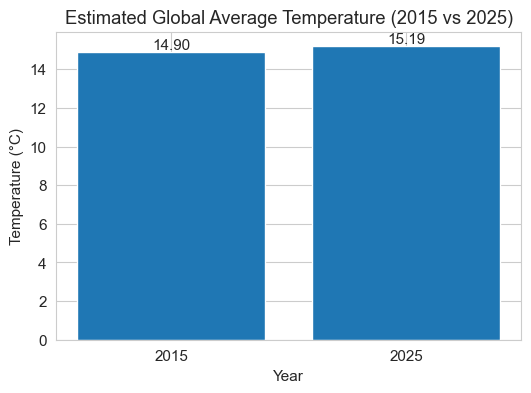

In [208]:
temp_df["global_avg_temp_C"] = 14 + pd.to_numeric(temp_df["temp_anomaly"])

absolute_df = temp_df[temp_df["year"].isin([2015, 2025])]

plt.figure(figsize=(6,4))
plt.bar(absolute_df["year"].astype(str), absolute_df["global_avg_temp_C"])

plt.title("Estimated Global Average Temperature (2015 vs 2025)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")

for i, v in enumerate(absolute_df["global_avg_temp_C"]):
    plt.text(i, v, f"{v:.2f}", ha="center", va="bottom")

plt.show()

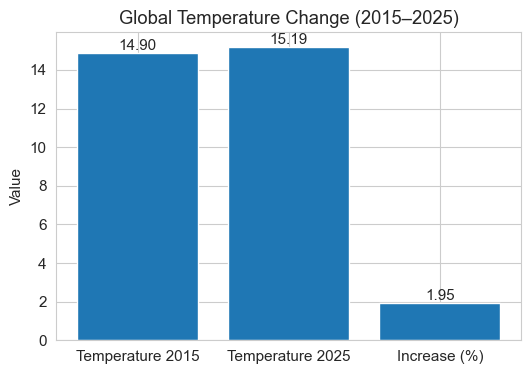

In [209]:
temp_2015 = absolute_df[absolute_df["year"] == 2015]["global_avg_temp_C"].values[0]
temp_2025 = absolute_df[absolute_df["year"] == 2025]["global_avg_temp_C"].values[0]

percent_increase = ((temp_2025 - temp_2015) / temp_2015) * 100

increase_df = pd.DataFrame({
    "metric": ["Temperature 2015", "Temperature 2025", "Increase (%)"],
    "value": [temp_2015, temp_2025, percent_increase]
})

plt.figure(figsize=(6,4))
plt.bar(increase_df["metric"], increase_df["value"])

plt.title("Global Temperature Change (2015–2025)")
plt.ylabel("Value")

for i, v in enumerate(increase_df["value"]):
    plt.text(i, v, f"{v:.2f}", ha="center", va="bottom")

plt.show()

Global temperature data shows a clear warming trend over the past decade. Temperature anomaly data, which measures the difference from a historical baseline, increased from approximately 0.9 °C in 2015 to about 1.19 °C in 2025, indicating that the planet has continued to warm. When converted to estimated absolute global temperatures, this corresponds to an increase from approximately 14.9 °C in 2015 to about 15.19 °C in 2025, representing a ~1.9% increase in global average temperature over the period. Although yearly values can fluctuate due to natural variability such as El Niño events, the overall trend confirms a sustained rise in global temperatures consistent with long-term climate change observations.

In [210]:
nasa_temp = temp_df[["year", "global_avg_temp_C"]].copy()
nasa_temp.head()

,year,global_avg_temp_C
0,1880,13.82
1,1881,13.90
2,1882,13.88
3,1883,13.82
4,1884,13.71


In [211]:
fossil_df = climate.groupby("year")["fossil_fuel_consumption"].sum().reset_index()

fossil_df.head()

,year,fossil_fuel_consumption
0,1980,1466.61
1,1981,1681.80
2,1982,1540.09
3,1983,1384.45
4,1984,1629.10


In [212]:
merged_df = pd.merge(nasa_temp, fossil_df, on="year", how="inner")

merged_df.tail()

,year,global_avg_temp_C,fossil_fuel_consumption
41,2021,14.85,1084.94
42,2022,14.90,816.29
43,2023,15.17,1369.04
44,2024,15.28,1505.61
45,2025,15.19,814.16


In [213]:
recent_df = merged_df[(merged_df["year"] >= 2015) & (merged_df["year"] <= 2025)]

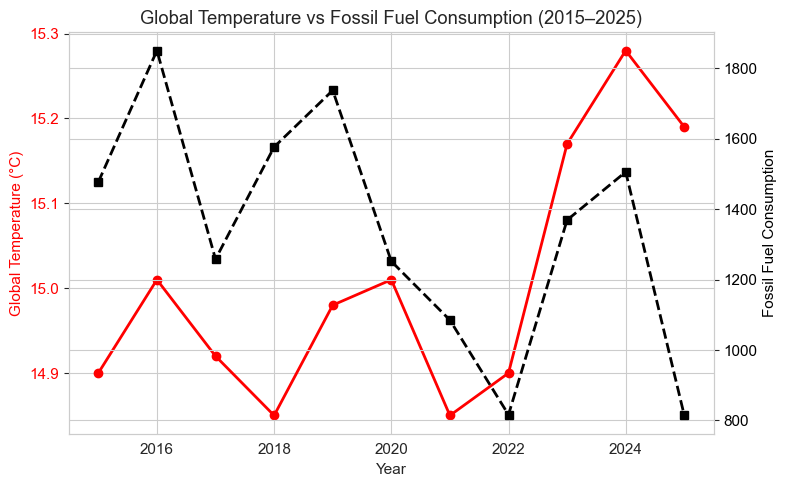

In [215]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8,5))

# Temperature line
ax1.plot(
    recent_df["year"],
    recent_df["global_avg_temp_C"],
    color="red",
    marker="o",
    linewidth=2,
    label="Global Temperature"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Global Temperature (°C)", color="red")
ax1.tick_params(axis="y", labelcolor="red")

# Second axis
ax2 = ax1.twinx()

ax2.plot(
    recent_df["year"],
    recent_df["fossil_fuel_consumption"],
    color="black",
    linestyle="--",
    marker="s",
    linewidth=2,
    label="Fossil Fuel Consumption"
)

ax2.set_ylabel("Fossil Fuel Consumption", color="black")
ax2.tick_params(axis="y", labelcolor="black")

plt.title("Global Temperature vs Fossil Fuel Consumption (2015–2025)")

fig.tight_layout()
plt.show()

In [217]:
ocean_df = pd.read_csv("../data/raw/realistic_ocean_climate_dataset.csv")

In [218]:
ocean_df.head()

,Date,Location,Latitude,Longitude,SST (°C),pH Level,Bleaching Severity,Species Observed,Marine Heatwave
0,2015-01-01,Red Sea,20.0248,38.4931,29.47,8.107,NaN,106,False
1,2015-01-07,Great Barrier Reef,-18.2988,147.7782,29.65,8.004,High,116,False
2,2015-01-14,Caribbean Sea,14.9768,-75.0233,28.86,7.947,High,90,False
3,2015-01-20,Great Barrier Reef,-18.3152,147.6486,28.97,7.995,Medium,94,False
4,2015-01-27,Galápagos,-0.8805,-90.9769,28.60,7.977,NaN,110,False


In [220]:
ocean_df["Date"] = pd.to_datetime(ocean_df["Date"])

In [221]:
ocean_df["year"] = ocean_df["Date"].dt.year

In [222]:
ocean_df[["Date","year"]].head()

,Date,year
0,2015-01-01,2015
1,2015-01-07,2015
2,2015-01-14,2015
3,2015-01-20,2015
4,2015-01-27,2015


In [223]:
recent_ocean = ocean_df[ocean_df["year"] >= 2015].copy()

In [224]:
recent_ocean_yearly = recent_ocean.groupby("year")["SST (°C)"].mean().reset_index()

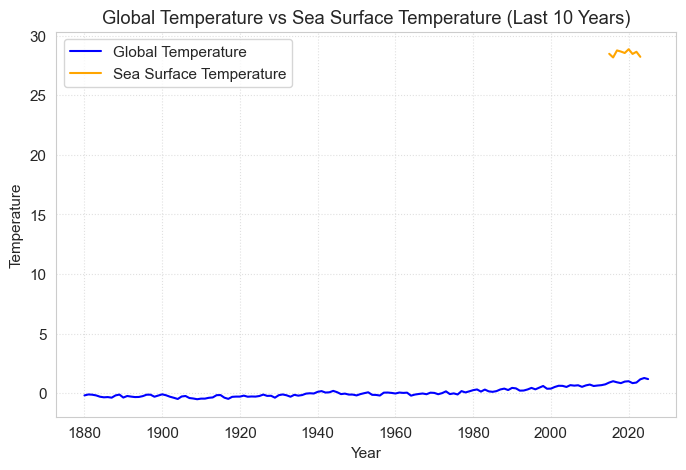

In [225]:
plt.figure(figsize=(8,5))

plt.plot(temp_df["year"], temp_df["temp_anomaly"], label="Global Temperature", color="blue")

plt.plot(recent_ocean_yearly["year"], recent_ocean_yearly["SST (°C)"], label="Sea Surface Temperature", color="orange")

plt.legend()
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.title("Global Temperature vs Sea Surface Temperature (Last 10 Years)")
plt.grid(True, linestyle=":", alpha=0.6)

plt.show()

In [230]:
ocean_df["Date"] = pd.to_datetime(ocean_df["Date"])
ocean_df["year"] = ocean_df["Date"].dt.year

ocean_yearly = ocean_df.groupby("year")["SST (°C)"].mean().reset_index()

In [231]:
temp_recent = temp_df[temp_df["year"] >= 2015][["year","temp_anomaly"]].copy()

In [232]:
combined = pd.merge(temp_recent, ocean_yearly, on="year", how="inner")

combined.head()

,year,temp_anomaly,SST (°C)
0,2015,0.90,28.481964
1,2016,1.01,28.173393
2,2017,0.92,28.764545
3,2018,0.85,28.670182
4,2019,0.98,28.547857


In [233]:
combined["temp_norm"] = (
    combined["temp_anomaly"] - combined["temp_anomaly"].mean()
) / combined["temp_anomaly"].std()

combined["sst_norm"] = (
    combined["SST (°C)"] - combined["SST (°C)"].mean()
) / combined["SST (°C)"].std()

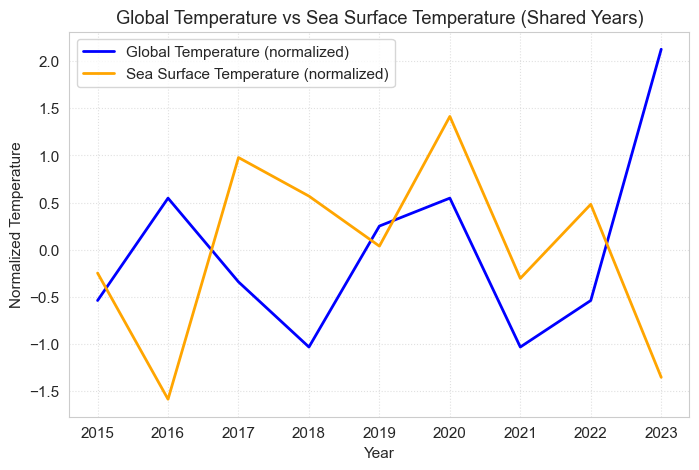

In [234]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    combined["year"],
    combined["temp_norm"],
    label="Global Temperature (normalized)",
    color="blue",
    linewidth=2
)

plt.plot(
    combined["year"],
    combined["sst_norm"],
    label="Sea Surface Temperature (normalized)",
    color="orange",
    linewidth=2
)

plt.title("Global Temperature vs Sea Surface Temperature (Shared Years)")
plt.xlabel("Year")
plt.ylabel("Normalized Temperature")

plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

plt.show()

In [235]:
fossil_yearly = climate.groupby("year")["fossil_fuel_consumption"].sum().reset_index()

fossil_yearly.head()

,year,fossil_fuel_consumption
0,1980,1466.61
1,1981,1681.80
2,1982,1540.09
3,1983,1384.45
4,1984,1629.10


In [236]:
fossil_2015 = fossil_yearly[fossil_yearly["year"] == 2015]["fossil_fuel_consumption"].values[0]
fossil_2025 = fossil_yearly[fossil_yearly["year"] == 2025]["fossil_fuel_consumption"].values[0]

In [237]:
fossil_increase_pct = ((fossil_2025 - fossil_2015) / fossil_2015) * 100

In [238]:
fossil_chart_df = pd.DataFrame({
    "metric": [
        "Fossil Fuel Consumption 2015",
        "Fossil Fuel Consumption 2025",
        "Increase (%)"
    ],
    "value": [
        fossil_2015,
        fossil_2025,
        fossil_increase_pct
    ]
})

fossil_chart_df

,metric,value
0,Fossil Fuel Consumption 2015,1476.970000
1,Fossil Fuel Consumption 2025,814.160000
2,Increase (%),-44.876335


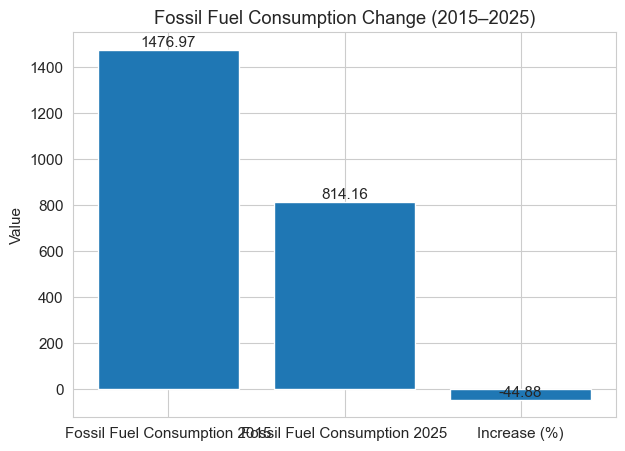

In [239]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.bar(
    fossil_chart_df["metric"],
    fossil_chart_df["value"],
)

plt.title("Fossil Fuel Consumption Change (2015–2025)")
plt.ylabel("Value")

for i, v in enumerate(fossil_chart_df["value"]):
    plt.text(i, v, f"{v:.2f}", ha="center", va="bottom")

plt.show()

In [240]:
fossil_df = pd.read_csv("../data/raw/global-fossil-fuel-consumption.csv")

fossil_df.head()

,Entity,Code,Year,Gas,Oil,Coal
0,World,OWID_WRL,1800,0.0,0.0,97.0
1,World,OWID_WRL,1810,0.0,0.0,128.0
2,World,OWID_WRL,1820,0.0,0.0,153.0
3,World,OWID_WRL,1830,0.0,0.0,264.0
4,World,OWID_WRL,1840,0.0,0.0,356.0


In [241]:
fossil_df.columns

Index(['Entity', 'Code', 'Year', 'Gas', 'Oil', 'Coal'], dtype='str')

In [243]:
fossil_df["fossil_total"] = fossil_df["Gas"] + fossil_df["Oil"] + fossil_df["Coal"]

In [245]:
# Create total fossil fuel consumption
fossil_df["fossil_total"] = fossil_df["Gas"] + fossil_df["Oil"] + fossil_df["Coal"]

# Extract 2015 and 2025 values
fossil_2015 = fossil_df[fossil_df["Year"] == 2015]["fossil_total"].values[0]
fossil_2025 = fossil_df[fossil_df["Year"] == 2025]["fossil_total"].values[0]

# Percentage increase
fossil_increase_pct = ((fossil_2025 - fossil_2015) / fossil_2015) * 100

print("2015:", fossil_2015)
print("2025:", fossil_2025)
print("Increase (%):", fossil_increase_pct)

IndexError: index 0 is out of bounds for axis 0 with size 0

In [246]:
fossil_df["Year"].max()

np.int64(2024)

In [247]:
fossil_2015 = fossil_df[fossil_df["Year"] == 2015]["fossil_total"].values[0]
fossil_2023 = fossil_df[fossil_df["Year"] == 2023]["fossil_total"].values[0]

In [248]:
fossil_increase_pct = ((fossil_2023 - fossil_2015) / fossil_2015) * 100

In [249]:
fossil_2015 = fossil_df.loc[fossil_df["Year"] == 2015, "fossil_total"].iloc[0]
fossil_latest = fossil_df.loc[fossil_df["Year"] == fossil_df["Year"].max(), "fossil_total"].iloc[0]

In [250]:
print("2015:", fossil_2015)
print("Latest year:", fossil_df["Year"].max())
print("Latest consumption:", fossil_latest)

2015: 129769.417
Latest year: 2024
Latest consumption: 142420.895


In [251]:
fossil_2014 = fossil_df.loc[fossil_df["Year"] == 2014, "fossil_total"].iloc[0]
fossil_2024 = fossil_df.loc[fossil_df["Year"] == 2024, "fossil_total"].iloc[0]

In [252]:
fossil_increase_pct = ((fossil_2024 - fossil_2014) / fossil_2014) * 100

In [253]:
fossil_chart_df = pd.DataFrame({
    "metric": [
        "Fossil Fuel Consumption 2014",
        "Fossil Fuel Consumption 2024",
        "Increase (%)"
    ],
    "value": [
        fossil_2014,
        fossil_2024,
        fossil_increase_pct
    ]
})

fossil_chart_df.round(2)

,metric,value
0,Fossil Fuel Consumption 2014,129225.12
1,Fossil Fuel Consumption 2024,142420.89
2,Increase (%),10.21


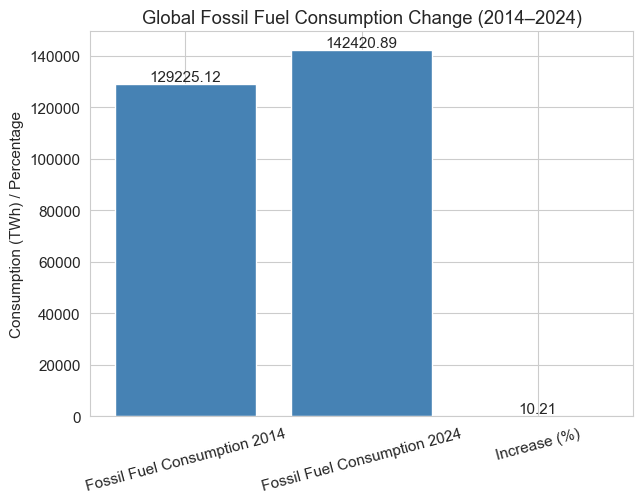

In [254]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

bars = plt.bar(
    fossil_chart_df["metric"],
    fossil_chart_df["value"],
    color=["steelblue","steelblue","darkorange"]
)

plt.title("Global Fossil Fuel Consumption Change (2014–2024)")
plt.ylabel("Consumption (TWh) / Percentage")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=15)
plt.show()

In [255]:
fossil_recent = fossil_df[fossil_df["Year"] >= 2014][["Year","fossil_total"]].copy()

In [256]:
temp_recent = temp_df[temp_df["year"] >= 2014][["year","global_avg_temp_C"]].copy()

In [257]:
combined = pd.merge(
    fossil_recent,
    temp_recent,
    left_on="Year",
    right_on="year",
    how="inner"
)

In [258]:
combined["fossil_norm"] = (
    combined["fossil_total"] - combined["fossil_total"].mean()
) / combined["fossil_total"].std()

combined["temp_norm"] = (
    combined["global_avg_temp_C"] - combined["global_avg_temp_C"].mean()
) / combined["global_avg_temp_C"].std()

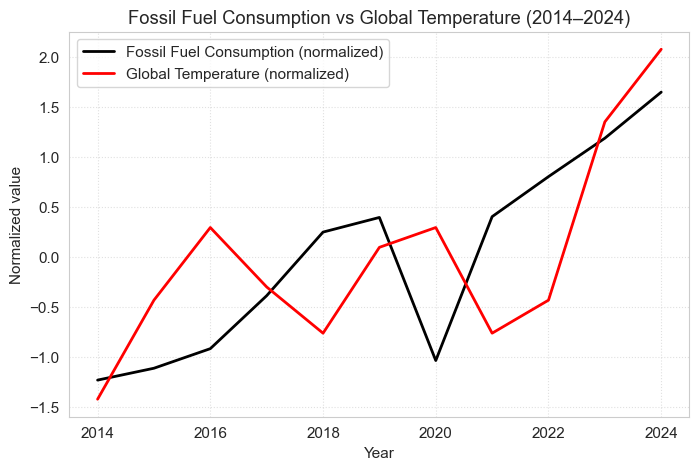

In [259]:
plt.figure(figsize=(8,5))

plt.plot(
    combined["Year"],
    combined["fossil_norm"],
    label="Fossil Fuel Consumption (normalized)",
    color="black",
    linewidth=2
)

plt.plot(
    combined["Year"],
    combined["temp_norm"],
    label="Global Temperature (normalized)",
    color="red",
    linewidth=2
)

plt.title("Fossil Fuel Consumption vs Global Temperature (2014–2024)")
plt.xlabel("Year")
plt.ylabel("Normalized value")

plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

plt.show()

In [260]:
co2_2015 = climate.loc[climate["year"] == 2015, "co2_concentration_ppm"].iloc[0]
co2_2025 = climate.loc[climate["year"] == 2025, "co2_concentration_ppm"].iloc[0]

In [261]:
co2_increase_pct = ((co2_2025 - co2_2015) / co2_2015) * 100

In [262]:
co2_chart_df = pd.DataFrame({
    "metric": [
        "CO2 Concentration 2015",
        "CO2 Concentration 2025",
        "Increase (%)"
    ],
    "value": [
        co2_2015,
        co2_2025,
        co2_increase_pct
    ]
})

co2_chart_df.round(2)

,metric,value
0,CO2 Concentration 2015,396.88
1,CO2 Concentration 2025,420.22
2,Increase (%),5.88


/Users/goncalotrindade/Desktop/git-practice/project-3/first_project/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


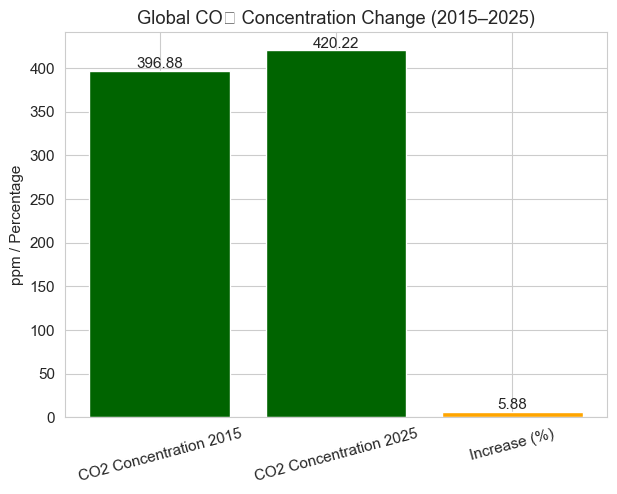

In [263]:
plt.figure(figsize=(7,5))

bars = plt.bar(
    co2_chart_df["metric"],
    co2_chart_df["value"],
    color=["darkgreen","darkgreen","orange"]
)

plt.title("Global CO₂ Concentration Change (2015–2025)")
plt.ylabel("ppm / Percentage")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=15)
plt.show()

In [264]:
ocean_df["year"] = pd.to_datetime(ocean_df["Date"]).dt.year

In [265]:
sea_yearly = ocean_df.groupby("year")["SST (°C)"].mean().reset_index()

In [267]:
# First check which years exist
print(sea_yearly["year"].tail(10))
print(sea_yearly["year"].max())

0    2015
1    2016
2    2017
3    2018
4    2019
5    2020
6    2021
7    2022
8    2023
Name: year, dtype: int32
2023


In [268]:
sea_2015_series = sea_yearly.loc[sea_yearly["year"] == 2015, "SST (°C)"]
sea_2025_series = sea_yearly.loc[sea_yearly["year"] == 2025, "SST (°C)"]

print(sea_2015_series)
print(sea_2025_series)

0    28.481964
Name: SST (°C), dtype: float64
Series([], Name: SST (°C), dtype: float64)


In [269]:
sea_2015_series = sea_yearly.loc[sea_yearly["year"] == 2015, "SST (°C)"]
sea_2025_series = sea_yearly.loc[sea_yearly["year"] == 2025, "SST (°C)"]

print(sea_2015_series)
print(sea_2025_series)

0    28.481964
Name: SST (°C), dtype: float64
Series([], Name: SST (°C), dtype: float64)


In [271]:
sea_yearly["year"].tail(15)

0    2015
1    2016
2    2017
3    2018
4    2019
5    2020
6    2021
7    2022
8    2023
Name: year, dtype: int32

In [272]:
sea_yearly["year"].max()

np.int32(2023)

In [274]:
sea_yearly["year"].max()

np.int32(2023)

In [276]:
sea_yearly["year"].head(10)

0    2015
1    2016
2    2017
3    2018
4    2019
5    2020
6    2021
7    2022
8    2023
Name: year, dtype: int32

In [277]:
sea_2015 = sea_yearly.loc[sea_yearly["year"] == 2015, "SST (°C)"].values[0]
sea_2023 = sea_yearly.loc[sea_yearly["year"] == 2023, "SST (°C)"].values[0]

print(sea_2015, sea_2023)

28.481964285714287 28.226964285714285


In [278]:
sea_increase_pct = ((sea_2023 - sea_2015) / sea_2015) * 100

print(sea_increase_pct)

-0.8953034188302211


In [279]:
sea_chart_df = pd.DataFrame({
    "metric": [
        "Sea Temperature 2015",
        "Sea Temperature 2023",
        "Increase (%)"
    ],
    "value": [
        sea_2015,
        sea_2023,
        sea_increase_pct
    ]
})

sea_chart_df.round(3)

,metric,value
0,Sea Temperature 2015,28.482
1,Sea Temperature 2023,28.227
2,Increase (%),-0.895


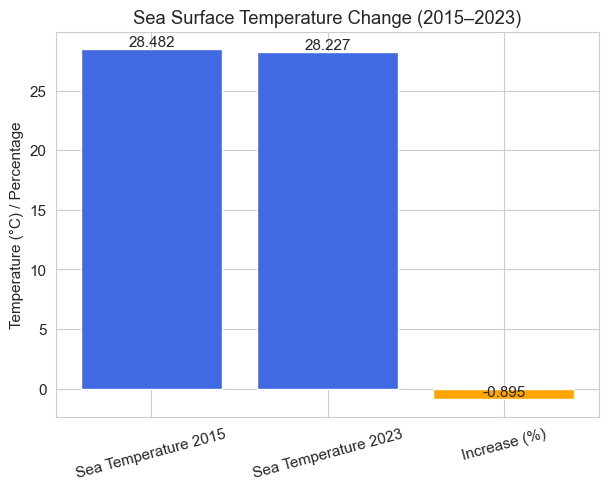

In [280]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

bars = plt.bar(
    sea_chart_df["metric"],
    sea_chart_df["value"],
    color=["royalblue", "royalblue", "orange"]
)

plt.title("Sea Surface Temperature Change (2015–2023)")
plt.ylabel("Temperature (°C) / Percentage")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=15)
plt.show()

In [281]:
temp_values_df = pd.DataFrame({
    "year": ["2015", "2025"],
    "temperature_C": [temp_2015, temp_2025]
})

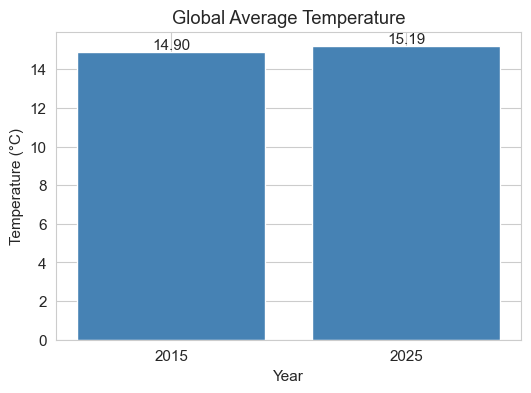

In [282]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

bars = plt.bar(
    temp_values_df["year"],
    temp_values_df["temperature_C"],
    color="steelblue"
)

plt.title("Global Average Temperature")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.show()

In [283]:
temp_pct_df = pd.DataFrame({
    "metric": ["Temperature Increase (2015–2025)"],
    "percent_change": [percentage_increase]
})

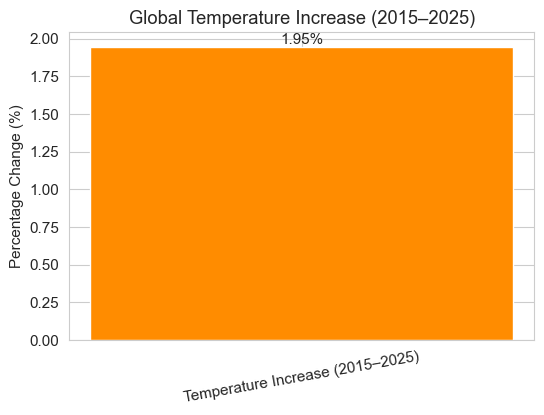

In [284]:
plt.figure(figsize=(6,4))

bars = plt.bar(
    temp_pct_df["metric"],
    temp_pct_df["percent_change"],
    color="darkorange"
)

plt.title("Global Temperature Increase (2015–2025)")
plt.ylabel("Percentage Change (%)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=10)
plt.show()

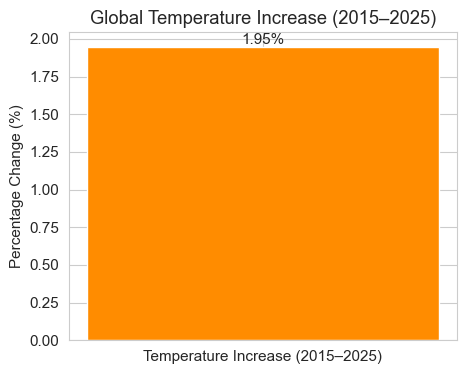

In [285]:
plt.figure(figsize=(5,4))

bars = plt.bar(
    temp_pct_df["metric"],
    temp_pct_df["percent_change"],
    color="darkorange",
    width=0.4
)

plt.title("Global Temperature Increase (2015–2025)")
plt.ylabel("Percentage Change (%)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.show()

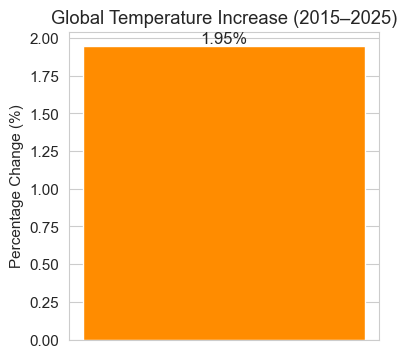

In [286]:
plt.figure(figsize=(4,4))

bars = plt.bar(
    ["Temperature Increase"],
    [percentage_increase],
    color="darkorange",
    width=0.5
)

plt.title("Global Temperature Increase (2015–2025)")
plt.ylabel("Percentage Change (%)")

plt.text(
    0,
    percentage_increase,
    f"{percentage_increase:.2f}%",
    ha="center",
    va="bottom",
    fontsize=12
)

plt.xticks([])
plt.show()

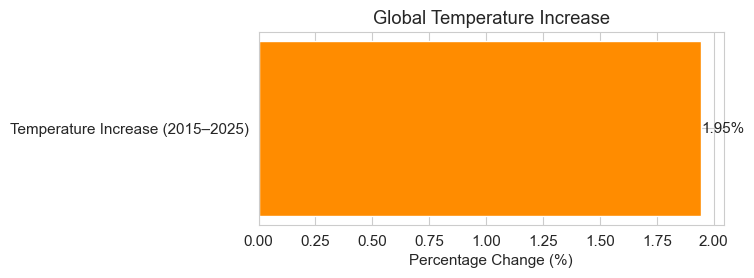

In [287]:
plt.figure(figsize=(6,2.5))

plt.barh(
    ["Temperature Increase (2015–2025)"],
    [percentage_increase],
    color="darkorange"
)

plt.xlabel("Percentage Change (%)")

plt.text(
    percentage_increase,
    0,
    f"{percentage_increase:.2f}%",
    va="center",
    ha="left"
)

plt.title("Global Temperature Increase")
plt.show()

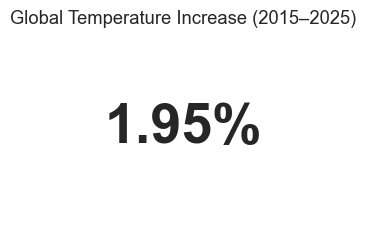

In [288]:
plt.figure(figsize=(4,2.5))

plt.text(
    0.5,
    0.5,
    f"{percentage_increase:.2f}%",
    ha="center",
    va="center",
    fontsize=40,
    fontweight="bold"
)

plt.title("Global Temperature Increase (2015–2025)")
plt.axis("off")

plt.show()

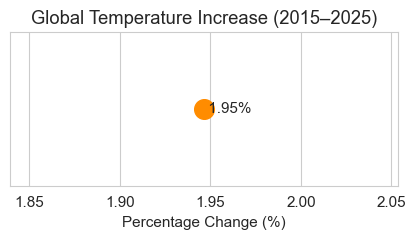

In [289]:
plt.figure(figsize=(5,2))

plt.scatter(
    percentage_increase,
    0,
    s=200,
    color="darkorange"
)

plt.text(
    percentage_increase,
    0,
    f" {percentage_increase:.2f}%",
    va="center"
)

plt.yticks([])
plt.xlabel("Percentage Change (%)")
plt.title("Global Temperature Increase (2015–2025)")

plt.show()

In [290]:
co2_2015 = climate.loc[climate["year"] == 2015, "co2_concentration_ppm"].iloc[0]
co2_2025 = climate.loc[climate["year"] == 2025, "co2_concentration_ppm"].iloc[0]

co2_pct = ((co2_2025 - co2_2015) / co2_2015) * 100

In [291]:
def_2015 = climate.loc[climate["year"] == 2015, "deforestation_rate"].iloc[0]
def_2025 = climate.loc[climate["year"] == 2025, "deforestation_rate"].iloc[0]

def_pct = ((def_2025 - def_2015) / def_2015) * 100

In [292]:
fossil_2015 = fossil_df.loc[fossil_df["Year"] == 2015, "fossil_total"].iloc[0]
fossil_2024 = fossil_df.loc[fossil_df["Year"] == 2024, "fossil_total"].iloc[0]

fossil_pct = ((fossil_2024 - fossil_2015) / fossil_2015) * 100

In [293]:
sea_2015 = sea_yearly.loc[sea_yearly["year"] == 2015, "SST (°C)"].iloc[0]
sea_2023 = sea_yearly.loc[sea_yearly["year"] == 2023, "SST (°C)"].iloc[0]

sea_pct = ((sea_2023 - sea_2015) / sea_2015) * 100

In [294]:
change_df = pd.DataFrame({
    "indicator": [
        "CO₂",
        "Deforestation",
        "Fossil Fuels",
        "Sea Temperature"
    ],
    "percent_change": [
        co2_pct,
        def_pct,
        fossil_pct,
        sea_pct
    ]
})

change_df.round(2)

,indicator,percent_change
0,CO₂,5.88
1,Deforestation,-50.55
2,Fossil Fuels,9.75
3,Sea Temperature,-0.90


/Users/goncalotrindade/Desktop/git-practice/project-3/first_project/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


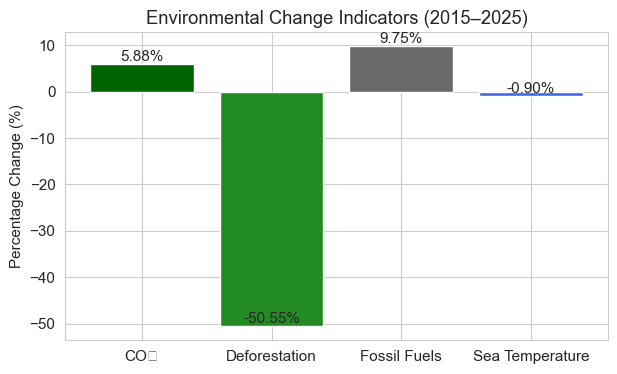

In [295]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

bars = plt.bar(
    change_df["indicator"],
    change_df["percent_change"],
    color=["darkgreen", "forestgreen", "dimgray", "royalblue"]
)

plt.title("Environmental Change Indicators (2015–2025)")
plt.ylabel("Percentage Change (%)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.show()

In [296]:
temp_2015 = temp_df.loc[temp_df["year"] == 2015, "global_avg_temp_C"].iloc[0]
temp_2025 = temp_df.loc[temp_df["year"] == 2025, "global_avg_temp_C"].iloc[0]

temp_pct = ((temp_2025 - temp_2015) / temp_2015) * 100

In [297]:
co2_2015 = climate.loc[climate["year"] == 2015, "co2_concentration_ppm"].iloc[0]
co2_2025 = climate.loc[climate["year"] == 2025, "co2_concentration_ppm"].iloc[0]

co2_pct = ((co2_2025 - co2_2015) / co2_2015) * 100

In [298]:
fossil_2015 = fossil_df.loc[fossil_df["Year"] == 2015, "fossil_total"].iloc[0]
fossil_2024 = fossil_df.loc[fossil_df["Year"] == 2024, "fossil_total"].iloc[0]

fossil_pct = ((fossil_2024 - fossil_2015) / fossil_2015) * 100

In [299]:
change_df = pd.DataFrame({
    "indicator": ["CO₂", "Fossil Fuels", "Global Temperature"],
    "percent_change": [co2_pct, fossil_pct, temp_pct]
})

change_df.round(2)

,indicator,percent_change
0,CO₂,5.88
1,Fossil Fuels,9.75
2,Global Temperature,1.95


/Users/goncalotrindade/Desktop/git-practice/project-3/first_project/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


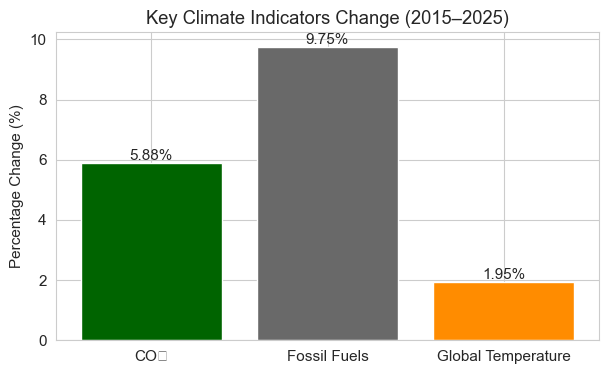

In [300]:
plt.figure(figsize=(7,4))

bars = plt.bar(
    change_df["indicator"],
    change_df["percent_change"],
    color=["darkgreen", "dimgray", "darkorange"]
)

plt.title("Key Climate Indicators Change (2015–2025)")
plt.ylabel("Percentage Change (%)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.show()

In [301]:
temp_2015 = temp_df.loc[temp_df["year"] == 2015, "global_avg_temp_C"].iloc[0]
temp_2025 = temp_df.loc[temp_df["year"] == 2025, "global_avg_temp_C"].iloc[0]

temp_pct = ((temp_2025 - temp_2015) / temp_2015) * 100

In [302]:
fossil_2015 = fossil_df.loc[fossil_df["Year"] == 2015, "fossil_total"].iloc[0]
fossil_2024 = fossil_df.loc[fossil_df["Year"] == 2024, "fossil_total"].iloc[0]

fossil_pct = ((fossil_2024 - fossil_2015) / fossil_2015) * 100

In [303]:
co2_2015 = climate.loc[climate["year"] == 2015, "co2_concentration_ppm"].iloc[0]
co2_2025 = climate.loc[climate["year"] == 2025, "co2_concentration_ppm"].iloc[0]

co2_pct = ((co2_2025 - co2_2015) / co2_2015) * 100

In [304]:
sea_2015 = sea_yearly.loc[sea_yearly["year"] == 2015, "SST (°C)"].iloc[0]
sea_2023 = sea_yearly.loc[sea_yearly["year"] == 2023, "SST (°C)"].iloc[0]

sea_pct = ((sea_2023 - sea_2015) / sea_2015) * 100

In [305]:
change_df = pd.DataFrame({
    "indicator": [
        "CO₂",
        "Fossil Fuels",
        "Global Temperature",
        "Sea Temperature"
    ],
    "percent_change": [
        co2_pct,
        fossil_pct,
        temp_pct,
        sea_pct
    ]
})

change_df.round(2)

,indicator,percent_change
0,CO₂,5.88
1,Fossil Fuels,9.75
2,Global Temperature,1.95
3,Sea Temperature,-0.90


In [307]:
noaa = pd.read_csv(
    "../data/raw/tas_NOAAGlobalTemp.csv",
    skiprows=28
)

noaa.head()

,,data
time,year,data
29219,1880,0.1321
29585,1881,0.1702
29950,1882,0.1561
30315,1883,0.0728


In [308]:
noaa.columns

Index(['data'], dtype='str')

In [310]:
noaa.columns

Index(['data'], dtype='str')

In [311]:
noaa.head()

,,data
time,year,data
29219,1880,0.1321
29585,1881,0.1702
29950,1882,0.1561
30315,1883,0.0728


In [313]:
print(noaa.columns)
print(noaa.head())

Index(['data'], dtype='str')
              data
time  year    data
29219 1880  0.1321
29585 1881  0.1702
29950 1882  0.1561
30315 1883  0.0728


In [315]:
noaa = pd.read_csv(
    "../data/raw/tas_NOAAGlobalTemp.csv",
    skiprows=28,
    sep=r"\s+",
    names=["year", "temp_anomaly"]
)

noaa.head()

,year,temp_anomaly
0,data,NaN
1,"time,year,data",NaN
2,"29219,1880,0.1321",NaN
3,"29585,1881,0.1702",NaN
4,"29950,1882,0.1561",NaN


In [317]:
print(noaa["year"].min(), noaa["year"].max())
print(noaa.tail())

29219,1880,0.1321 time,year,data
                  year temp_anomaly
141  79988,2019,1.1936          NaN
142  80353,2020,1.2275          NaN
143  80719,2021,1.0922          NaN
144  81084,2022,1.1057          NaN
145                end         data


In [318]:
temp_2015 = noaa.loc[noaa["year"] == 2015, "temp_anomaly"].iloc[0]
temp_2022 = noaa.loc[noaa["year"] == 2022, "temp_anomaly"].iloc[0]

temp_pct = ((temp_2022 - temp_2015) / abs(temp_2015)) * 100

print(temp_2015, temp_2022, temp_pct)

IndexError: single positional indexer is out-of-bounds

In [319]:
# clean NOAA dataframe properly
noaa = noaa.copy()
noaa["year"] = pd.to_numeric(noaa["year"], errors="coerce")
noaa["temp_anomaly"] = pd.to_numeric(noaa["temp_anomaly"], errors="coerce")

noaa = noaa.dropna(subset=["year", "temp_anomaly"])
noaa["year"] = noaa["year"].astype(int)

# check the range
print(noaa["year"].min(), noaa["year"].max())
print(noaa.tail())

# extract values safely
temp_2015_series = noaa.loc[noaa["year"] == 2015, "temp_anomaly"]
temp_2022_series = noaa.loc[noaa["year"] == 2022, "temp_anomaly"]

print(temp_2015_series)
print(temp_2022_series)

nan nan
Empty DataFrame
Columns: [year, temp_anomaly]
Index: []
Series([], Name: temp_anomaly, dtype: float64)
Series([], Name: temp_anomaly, dtype: float64)


In [320]:
temp_2015 = temp_2015_series.iloc[0]
temp_2022 = temp_2022_series.iloc[0]

temp_pct = ((temp_2022 - temp_2015) / abs(temp_2015)) * 100
print(temp_2015, temp_2022, temp_pct)

IndexError: single positional indexer is out-of-bounds

In [321]:
import pandas as pd

noaa = pd.read_csv(
    "../data/raw/tas_NOAAGlobalTemp.csv",
    skiprows=29,
    sep=",",
    names=["time", "year", "temp_anomaly"],
    engine="python"
)

# Clean it
noaa["year"] = pd.to_numeric(noaa["year"], errors="coerce")
noaa["temp_anomaly"] = pd.to_numeric(noaa["temp_anomaly"], errors="coerce")

noaa = noaa.dropna(subset=["year", "temp_anomaly"]).copy()
noaa["year"] = noaa["year"].astype(int)

print(noaa.head())
print(noaa.tail())
print(noaa["year"].min(), noaa["year"].max())

    time  year  temp_anomaly
1  29219  1880        0.1321
2  29585  1881        0.1702
3  29950  1882        0.1561
4  30315  1883        0.0728
5  30680  1884       -0.0136
      time  year  temp_anomaly
139  79623  2018        1.0697
140  79988  2019        1.1936
141  80353  2020        1.2275
142  80719  2021        1.0922
143  81084  2022        1.1057
1880 2022


In [322]:
temp_2015 = noaa.loc[noaa["year"] == 2015, "temp_anomaly"].iloc[0]
temp_2022 = noaa.loc[noaa["year"] == 2022, "temp_anomaly"].iloc[0]

temp_pct = ((temp_2022 - temp_2015) / abs(temp_2015)) * 100

print(temp_2015, temp_2022, temp_pct)

1.1749 1.1057 -5.889862967061039


In [323]:
ocean = pd.read_csv("../data/raw/realistic_ocean_climate_dataset.csv")

ocean.head()

,Date,Location,Latitude,Longitude,SST (°C),pH Level,Bleaching Severity,Species Observed,Marine Heatwave
0,2015-01-01,Red Sea,20.0248,38.4931,29.47,8.107,NaN,106,False
1,2015-01-07,Great Barrier Reef,-18.2988,147.7782,29.65,8.004,High,116,False
2,2015-01-14,Caribbean Sea,14.9768,-75.0233,28.86,7.947,High,90,False
3,2015-01-20,Great Barrier Reef,-18.3152,147.6486,28.97,7.995,Medium,94,False
4,2015-01-27,Galápagos,-0.8805,-90.9769,28.60,7.977,NaN,110,False


In [324]:
ocean.columns

Index(['Date', 'Location', 'Latitude', 'Longitude', 'SST (°C)', 'pH Level',
       'Bleaching Severity', 'Species Observed', 'Marine Heatwave'],
      dtype='str')

In [326]:
# Convert Date to datetime and extract year
ocean["Date"] = pd.to_datetime(ocean["Date"])
ocean["year"] = ocean["Date"].dt.year

# Compute yearly average sea surface temperature
sea_yearly = ocean.groupby("year")["SST (°C)"].mean().reset_index()

# Check available years
print(sea_yearly["year"].min(), sea_yearly["year"].max())
print(sea_yearly)

2015 2023
   year   SST (°C)
0  2015  28.481964
1  2016  28.173393
2  2017  28.764545
3  2018  28.670182
4  2019  28.547857
5  2020  28.865091
6  2021  28.468929
7  2022  28.650182
8  2023  28.226964


In [328]:
ocean["Date"] = pd.to_datetime(ocean["Date"])
ocean["year"] = ocean["Date"].dt.year

print(ocean["year"].min(), ocean["year"].max())
print(sorted(ocean["year"].unique()))

2015 2023
[np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023)]


In [329]:
ocean["Date"] = pd.to_datetime(ocean["Date"])
ocean["year"] = ocean["Date"].dt.year

In [330]:
sea_yearly = ocean.groupby("year")["SST (°C)"].mean().reset_index()

sea_yearly

,year,SST (°C)
0,2015,28.481964
1,2016,28.173393
2,2017,28.764545
3,2018,28.670182
4,2019,28.547857
5,2020,28.865091
6,2021,28.468929
7,2022,28.650182
8,2023,28.226964


In [332]:
sea_2015 = sea_yearly.loc[sea_yearly["year"] == 2015, "SST (°C)"].iloc[0]
sea_2023 = sea_yearly.loc[sea_yearly["year"] == 2023, "SST (°C)"].iloc[0]

print(sea_2015, sea_2023)

28.481964285714287 28.226964285714285


In [333]:
sea_pct = ((sea_2023 - sea_2015) / sea_2015) * 100

print(sea_pct)

-0.8953034188302211


In [334]:
sea_indicator_df = pd.DataFrame({
    "metric": ["Sea Temperature 2015", "Sea Temperature 2023", "Increase (%)"],
    "value": [sea_2015, sea_2023, sea_pct]
})

sea_indicator_df.round(3)

,metric,value
0,Sea Temperature 2015,28.482
1,Sea Temperature 2023,28.227
2,Increase (%),-0.895


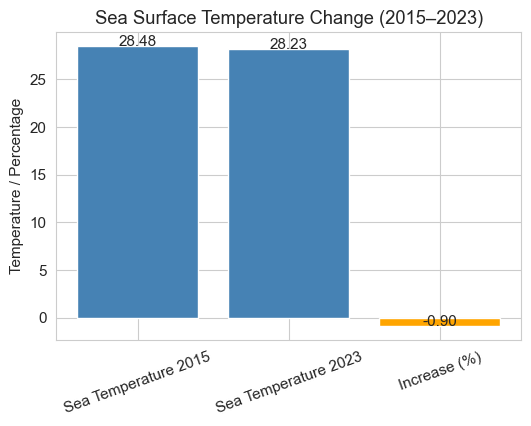

In [335]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

bars = plt.bar(
    sea_indicator_df["metric"],
    sea_indicator_df["value"],
    color=["steelblue", "steelblue", "orange"]
)

plt.title("Sea Surface Temperature Change (2015–2023)")
plt.ylabel("Temperature / Percentage")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center"
    )

plt.xticks(rotation=20)
plt.show()

                      indicator  percent_change
0              CO₂\n(2015–2025)            5.88
1     Fossil Fuels\n(2015–2024)            9.75
2  Sea Temperature\n(2015–2023)           -0.90


/var/folders/b7/yg62l3k53kvc1lvmnwswr23m0000gn/T/ipykernel_6323/2253452169.py:48: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/goncalotrindade/Desktop/git-practice/project-3/first_project/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


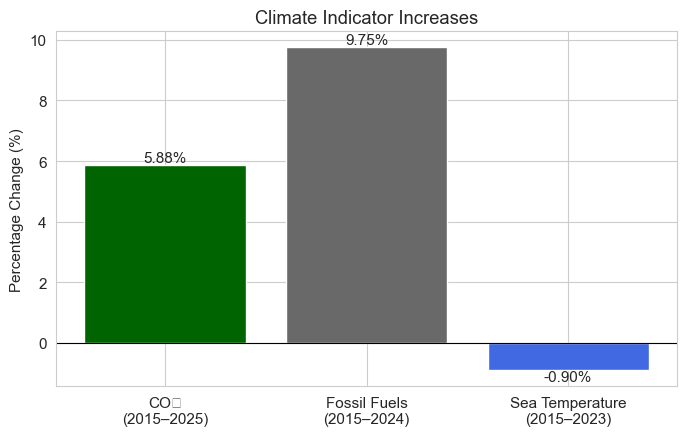

In [336]:
import pandas as pd
import matplotlib.pyplot as plt

# Percent changes
co2_pct = ((co2_2025 - co2_2015) / co2_2015) * 100
fossil_pct = ((fossil_2024 - fossil_2015) / fossil_2015) * 100
sea_pct = ((sea_2023 - sea_2015) / sea_2015) * 100

# Combined dataframe
change_df = pd.DataFrame({
    "indicator": [
        "CO₂\n(2015–2025)",
        "Fossil Fuels\n(2015–2024)",
        "Sea Temperature\n(2015–2023)"
    ],
    "percent_change": [
        co2_pct,
        fossil_pct,
        sea_pct
    ]
})

change_df = change_df.round(2)
print(change_df)

# Plot
plt.figure(figsize=(7, 4.5))

bars = plt.bar(
    change_df["indicator"],
    change_df["percent_change"],
    color=["darkgreen", "dimgray", "royalblue"]
)

plt.title("Climate Indicator Increases")
plt.ylabel("Percentage Change (%)")
plt.axhline(0, color="black", linewidth=0.8)

for bar, value in zip(bars, change_df["percent_change"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom" if value >= 0 else "top"
    )

plt.tight_layout()
plt.show()